# Task 4 — Fashion Visual Search

**COSC2753 Assignment 2** · Content-based image retrieval

Given a query fashion image, retrieve the Top-K most visually similar items from the ~38,600
image gallery. There is no class to predict: the system must **rank** the entire gallery.

## How retrieval differs from classification

Tasks 1–3 map an image to one of a few labels. Here the output is an ordering over 38,000
items, so the model's job is to produce an **embedding** — a vector per image such that similar
items land close together. Retrieval is then a nearest-neighbour lookup in that space.

Every method below therefore has the same shape:

```
image ──> embedding vector ──> cosine similarity against all gallery vectors ──> Top-K
```

Only the middle step differs, which makes the four methods directly comparable.

## Methods compared

| # | Method | Supervision | What it captures |
|---|---|---|---|
| 1 | Colour histogram + gradient orientations | none (hand-crafted) | raw appearance: colour and edges |
| 2 | Task 3 CNN features | reuses the multi-task classifier | garment semantics learned for gender/usage |
| 3 | Convolutional autoencoder | unsupervised reconstruction | visual structure, no label information |
| 4 | Triplet metric learning | `articleType` as weak supervision | a space trained *specifically* so similar items are close |

Method 2 reuses the network trained in `04_task3_gender_usage.ipynb`. This is permitted: it was
trained only on assignment data, not on an external corpus. No pretrained weights are used
anywhere in this notebook.

## The evaluation problem

The dataset contains no ground-truth "these two items are similar" labels, so relevance must be
defined from metadata. A retrieved item counts as **relevant** if it shares the query's
`articleType`. This is strict and easy to defend, and it is reported alongside a **graded**
measure (nDCG) that gives partial credit for sharing `subCategory` or `masterCategory`.

Two evaluation modes are reported for every method:

* **Standard** — the query is excluded from its own results, nothing else is removed.
* **Strict** — every item sharing the query's `productDisplayName` is also removed. The EDA
  found over 15,000 rows sharing a product name, i.e. near-identical photographs of the same
  product. Retrieving those is trivial and inflates the score, so the strict mode is the
  honest measure of generalisation.

## 1. Setup and configuration

In [1]:
# ============================================
# CELL 1 - Imports, device and reproducibility
# ============================================

import os
import re
import json
import time
import copy
import random
import warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from PIL import Image

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)

RANDOM_STATE = 42


def set_seed(seed=RANDOM_STATE):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("Device :", DEVICE)
if DEVICE.type == "cuda":
    print("GPU    :", torch.cuda.get_device_name(0))
    torch.backends.cudnn.benchmark = True

PyTorch: 2.11.0+cu128
Device : cuda
GPU    : NVIDIA GeForce RTX 3060 Laptop GPU


In [2]:
# ============================================
# CELL 2 - Paths
# ============================================

NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR = NOTEBOOK_DIR.parent

DATASET_ROOT = PROJECT_DIR / "A2_FashionDataset"
DATASET_DIR = DATASET_ROOT / "FashionDataset"

TRAIN_IMAGE_DIR = DATASET_DIR / "train" / "images_train"
TEST_IMAGE_DIR = DATASET_DIR / "test" / "images_test"

PROCESSED_DIR = DATASET_ROOT / "processed"
TASK3_ARTIFACTS = PROJECT_DIR / "artifacts" / "task3"
ARTIFACT_DIR = PROJECT_DIR / "artifacts" / "task4"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

CLEAN_METADATA = PROCESSED_DIR / "clean_train_metadata.csv"
PREDICTION_METADATA = PROCESSED_DIR / "prediction_metadata.csv"

assert CLEAN_METADATA.exists(), (
    f"Cannot find {CLEAN_METADATA}. Run 01_eda.ipynb first."
)

print("Processed directory:", PROCESSED_DIR)
print("Artifact directory :", ARTIFACT_DIR)
print("Task 3 model found :", (TASK3_ARTIFACTS / "task3_multitask_cnn.pt").exists())

Processed directory: c:\Users\LEGION\Documents\jupyter_notebook\Fashion-Intelligence-System\A2_FashionDataset\processed
Artifact directory : c:\Users\LEGION\Documents\jupyter_notebook\Fashion-Intelligence-System\artifacts\task4
Task 3 model found : True


In [3]:
# ============================================
# CELL 3 - Configuration
# ============================================

CONFIG = {
    # --- image ---
    "image_width": 60,          # native resolution from the EDA scan
    "image_height": 80,

    # --- which embedding methods to build (set False to save time) ---
    "run_classical": True,      # instant
    "run_task3_cnn": True,      # no training, just a forward pass
    "run_autoencoder": True,    # trains a small conv autoencoder
    "run_triplet": True,        # trains a metric-learning encoder

    # --- retrieval ---
    "top_k": 10,                 # K for the headline metrics
    "k_values": [1, 5, 10, 20],  # K values reported in the tables
    "embedding_dim": 128,        # bottleneck size for the learned encoders

    # --- evaluation ---
    "n_queries": 2000,           # sampled query set; raise for tighter estimates
    "relevance": "articleType",  # a hit shares this attribute with the query
    # Secondary attribute the Triplet model was NOT trained on. Evaluating on it
    # removes the structural advantage that method has under `relevance`, because
    # it was optimised for exactly that attribute. See section 10b.
    "relevance_control": "baseColour",
    # Random sampling is dominated by common classes (Watches contributed 103 of
    # 2000 queries in RUN 1, while several types contributed one). Stratified
    # sampling caps the contribution of any single class so rare types are measured.
    "stratified_queries": True,
    "max_queries_per_class": 40,

    # --- realistic-use-case protocol (section 10c) ---
    # The deployed system receives a photo that is NOT in the catalogue. Holding
    # out whole PRODUCTS (not rows) gives queries the encoders have never seen,
    # and simultaneously removes the duplicate-photo problem for free.
    "holdout_fraction": 0.15,

    # --- improvements evaluated in section 10c ---
    "aug_flip": True,            # horizontal flip during training
    "aug_photometric": 0.15,     # +-15% brightness/contrast jitter; 0 disables
    "aux_type_weight": 0.5,      # auxiliary articleType classification loss
    "aux_colour_weight": 0.5,    # auxiliary baseColour loss - keeps colour in the embedding
    "use_tta": True,             # average the embedding of the image and its mirror
    "rerank_alpha": 0.8,         # embedding vs colour weight when re-ranking

    # --- training ---
    "batch_size": 128,
    "autoencoder_epochs": 15,
    "triplet_epochs": 30,        # RUN 5: all three losses still falling at 12
    "learning_rate": 1e-3,
    "triplet_margin": 0.3,
    "num_workers": 0,            # keep 0 on Windows/Jupyter
}

IMAGE_SIZE_PIL = (CONFIG["image_width"], CONFIG["image_height"])
IMAGE_SHAPE = (CONFIG["image_height"], CONFIG["image_width"], 3)

print(json.dumps(CONFIG, indent=2))

{
  "image_width": 60,
  "image_height": 80,
  "run_classical": true,
  "run_task3_cnn": true,
  "run_autoencoder": true,
  "run_triplet": true,
  "top_k": 10,
  "k_values": [
    1,
    5,
    10,
    20
  ],
  "embedding_dim": 128,
  "n_queries": 2000,
  "relevance": "articleType",
  "relevance_control": "baseColour",
  "stratified_queries": true,
  "max_queries_per_class": 40,
  "holdout_fraction": 0.15,
  "aug_flip": true,
  "aug_photometric": 0.15,
  "aux_type_weight": 0.5,
  "aux_colour_weight": 0.5,
  "use_tta": true,
  "rerank_alpha": 0.8,
  "batch_size": 128,
  "autoencoder_epochs": 15,
  "triplet_epochs": 30,
  "learning_rate": 0.001,
  "triplet_margin": 0.3,
  "num_workers": 0
}


## 2. Gallery construction

The gallery is every training image with usable metadata — the same cleaned file the other
notebooks consume. Unlike Task 3, **no rows are dropped for rare labels**: retrieval has no
class imbalance problem, and a rare item should still be findable.

In [4]:
# ============================================
# CELL 4 - Load the gallery metadata
# ============================================

gallery = pd.read_csv(CLEAN_METADATA).reset_index(drop=True)
gallery["position"] = np.arange(len(gallery))     # row index == embedding row index

print("Gallery size:", len(gallery))
print("Distinct articleType :", gallery["articleType"].nunique())
print("Distinct subCategory :", gallery["subCategory"].nunique())
print("Distinct baseColour  :", gallery["baseColour"].nunique())

display(gallery[["id", "articleType", "subCategory", "masterCategory",
                 "baseColour", "gender", "productDisplayName"]].head())

print("\nMost common articleTypes:")
display(gallery["articleType"].value_counts().head(10).to_frame("Count"))

Gallery size: 38612
Distinct articleType : 124
Distinct subCategory : 41
Distinct baseColour  : 46


,id,articleType,subCategory,masterCategory,baseColour,gender,productDisplayName
0,1163,Tshirts,Topwear,Apparel,Blue,Men,Nike Sahara Team India Fanwear Round Neck Jersey
1,1164,Tshirts,Topwear,Apparel,Blue,Men,Nike Men Blue T20 Indian Cricket Jersey
2,1165,Tshirts,Topwear,Apparel,Blue,Men,Nike Mean Team India Cricket Jersey
3,1525,Backpacks,Bags,Accessories,Navy Blue,Unisex,Puma Deck Navy Blue Backpack
4,1526,Backpacks,Bags,Accessories,Black,Unisex,Puma Big Cat Backpack Black



Most common articleTypes:


,Count
articleType,
Tshirts,6780
Shirts,3087
Casual Shoes,2683
Watches,2252
Sports Shoes,1991
Tops,1614
Kurtas,1556
Handbags,1439
Heels,1048


In [5]:
# ============================================
# CELL 5 - Image cache for the whole gallery
# ============================================

CACHE_X = PROCESSED_DIR / f"search_cache_{CONFIG['image_width']}x{CONFIG['image_height']}.npy"
CACHE_IDS = PROCESSED_DIR / f"search_cache_{CONFIG['image_width']}x{CONFIG['image_height']}_ids.npy"


def load_image_array(path, size=IMAGE_SIZE_PIL):
    """Single source of truth for reading one image (gallery and queries alike)."""
    with Image.open(path) as img:
        img = img.convert("RGB").resize(size, Image.BILINEAR)
        return np.asarray(img, dtype=np.uint8)


gallery_ids = gallery["id"].to_numpy()
rebuild = True

if CACHE_X.exists() and CACHE_IDS.exists():
    cached = np.load(CACHE_IDS)
    if len(cached) == len(gallery_ids) and (cached == gallery_ids).all():
        IMAGES = np.load(CACHE_X, mmap_mode="r")
        rebuild = False
        print("Loaded image cache:", IMAGES.shape, IMAGES.dtype)
    else:
        print("Cache does not match the gallery - rebuilding")

if rebuild:
    print(f"Building cache for {len(gallery)} images ...")
    IMAGES = np.lib.format.open_memmap(
        CACHE_X, mode="w+", dtype=np.uint8, shape=(len(gallery),) + IMAGE_SHAPE)
    start = time.time()
    for position, path in enumerate(gallery["image_path"]):
        IMAGES[position] = load_image_array(path)
        if (position + 1) % 10000 == 0:
            print(f"  {position + 1}/{len(gallery)} ({time.time() - start:.0f}s)")
    IMAGES.flush()
    np.save(CACHE_IDS, gallery_ids)
    print(f"Cache built in {time.time() - start:.0f}s")

# alignment check
probe = gallery.sample(1, random_state=RANDOM_STATE).iloc[0]
assert np.array_equal(np.asarray(IMAGES[probe["position"]]),
                      load_image_array(probe["image_path"])), "Cache is misaligned"
print("Cache alignment verified. Memory footprint:",
      round(IMAGES.nbytes / 1e6, 1), "MB")

Loaded image cache: (38612, 80, 60, 3) uint8
Cache alignment verified. Memory footprint: 556.0 MB


## 3. Evaluation framework

Defined **before** any method is built, so no method can be tuned against a metric invented
afterwards.

**Relevance.** A retrieved item is a hit if it shares the query's `articleType`.

**Metrics.**

* **Precision@K** — of the K returned items, what fraction are relevant. The number a user
  experiences directly.
* **Recall@K** — of all relevant items in the gallery, what fraction appeared in the top K.
  Low by construction when a class has thousands of members, so it is read as a trend.
* **mAP@K** — mean average precision; rewards putting the relevant items *earlier*.
* **nDCG@K** — uses graded relevance (same `articleType` = 1.0, same `subCategory` = 0.5,
  same `masterCategory` = 0.25) so a near-miss scores better than a nonsense result.

**Random baseline.** Retrieving K items at random gives a Precision@K equal to the class's
share of the gallery. Every method is compared against that floor.

In [6]:
# ============================================
# CELL 6 - Relevance definitions
# ============================================

RELEVANCE_COL = CONFIG["relevance"]

article = gallery[RELEVANCE_COL].to_numpy()
subcat = gallery["subCategory"].to_numpy()
mastercat = gallery["masterCategory"].to_numpy()
product_name = gallery["productDisplayName"].fillna("").to_numpy()


def binary_relevance(query_position, result_positions):
    """1 if the retrieved item shares the query's articleType, else 0."""
    return (article[result_positions] == article[query_position]).astype(float)


def graded_relevance(query_position, result_positions):
    """Partial credit for sharing a broader category."""
    grades = np.zeros(len(result_positions), dtype=float)
    grades[mastercat[result_positions] == mastercat[query_position]] = 0.25
    grades[subcat[result_positions] == subcat[query_position]] = 0.5
    grades[article[result_positions] == article[query_position]] = 1.0
    return grades


# How many items share each attribute - needed for Recall@K and for the nDCG ideal
class_counts = gallery[RELEVANCE_COL].value_counts()
relevant_total = gallery[RELEVANCE_COL].map(class_counts).to_numpy() - 1   # exclude self

subcat_counts = gallery["subCategory"].value_counts()
subcat_total = gallery["subCategory"].map(subcat_counts).to_numpy() - 1

master_counts = gallery["masterCategory"].value_counts()
master_total = gallery["masterCategory"].map(master_counts).to_numpy() - 1

print(f"Relevance attribute: {RELEVANCE_COL}")
print(f"Classes: {len(class_counts)}")
print(f"Largest: {class_counts.index[0]} ({class_counts.iloc[0]} items, "
      f"{class_counts.iloc[0] / len(gallery) * 100:.1f}% of the gallery)")
print(f"Smallest: {class_counts.index[-1]} ({class_counts.iloc[-1]} items)")
print(f"\nRandom-retrieval Precision@K floor (weighted by class size): "
      f"{(class_counts / len(gallery) * class_counts).sum() / len(gallery) * 100:.2f}%")

Relevance attribute: articleType
Classes: 124
Largest: Tshirts (6780 items, 17.6% of the gallery)
Smallest: Lounge Tshirts (1 items)

Random-retrieval Precision@K floor (weighted by class size): 5.91%


In [7]:
# ============================================
# CELL 7 - Retrieval metrics
# ============================================

def dcg(gains):
    positions = np.arange(1, len(gains) + 1)
    return float((gains / np.log2(positions + 1)).sum())


def ideal_gains(query_position, k):
    """Best achievable grade vector for this query - NOT simply k perfect matches.

    A query whose articleType has only 3 other members cannot fill 10 slots with
    exact matches. Using ones(k) as the ideal (as RUN 1 did) therefore understates
    nDCG for exactly the rare classes the metric is meant to protect.
    """
    n_exact = min(int(relevant_total[query_position]), k)
    remaining = k - n_exact

    n_sub = min(int(subcat_total[query_position]) - int(relevant_total[query_position]),
                remaining)
    n_sub = max(n_sub, 0)
    remaining -= n_sub

    n_master = min(int(master_total[query_position]) - int(subcat_total[query_position]),
                   remaining)
    n_master = max(n_master, 0)
    remaining -= n_master

    gains = np.concatenate([
        np.ones(n_exact),
        np.full(n_sub, 0.5),
        np.full(n_master, 0.25),
        np.zeros(max(remaining, 0)),
    ])
    return gains[:k]


def evaluate_ranking(query_position, ranked_positions, k_values):
    """Metrics for one query, given gallery positions ranked most-similar first."""
    out = {}
    max_k = max(k_values)
    top = ranked_positions[:max_k]

    hits = binary_relevance(query_position, top)
    grades = graded_relevance(query_position, top)
    n_relevant = max(int(relevant_total[query_position]), 1)

    for k in k_values:
        hits_k = hits[:k]
        out[f"P@{k}"] = float(hits_k.mean())
        out[f"R@{k}"] = float(hits_k.sum() / n_relevant)

        # average precision at k, normalised by the achievable number of hits
        achievable = min(k, n_relevant)
        if hits_k.sum() > 0:
            precisions = np.cumsum(hits_k) / np.arange(1, k + 1)
            out[f"AP@{k}"] = float((precisions * hits_k).sum() / achievable)
        else:
            out[f"AP@{k}"] = 0.0

        # nDCG against the best ranking that is actually possible for this query
        ideal = dcg(ideal_gains(query_position, k))
        out[f"nDCG@{k}"] = dcg(grades[:k]) / ideal if ideal > 0 else 0.0

    # R-precision: precision at K = number of relevant items. Comparable across
    # classes of wildly different size, unlike Recall@10.
    r = min(n_relevant, len(ranked_positions))
    out["R-precision"] = float(binary_relevance(query_position,
                                                ranked_positions[:r]).mean()) if r else 0.0
    return out


print("Metric functions defined:")
print("  P@K         - precision at K")
print("  R@K         - recall at K (reported, but see the caveat below)")
print("  AP@K        - average precision, normalised by the achievable hit count")
print("  nDCG@K      - graded relevance against the BEST ACHIEVABLE ranking")
print("  R-precision - precision at K = number of relevant items")
print()
print("CAVEAT on Recall@K: with 6,781 Tshirts in the gallery, ten results can")
print("recover at most 0.15% of them, so R@10 is near-zero by construction and")
print("is not comparable across classes. R-precision is the size-invariant")
print("alternative and should be preferred in the report.")

Metric functions defined:
  P@K         - precision at K
  R@K         - recall at K (reported, but see the caveat below)
  AP@K        - average precision, normalised by the achievable hit count
  nDCG@K      - graded relevance against the BEST ACHIEVABLE ranking
  R-precision - precision at K = number of relevant items

CAVEAT on Recall@K: with 6,781 Tshirts in the gallery, ten results can
recover at most 0.15% of them, so R@10 is near-zero by construction and
is not comparable across classes. R-precision is the size-invariant
alternative and should be preferred in the report.


## 4. The search engine

Embeddings are L2-normalised, which makes the cosine similarity between two vectors a single
dot product. Similarity against the whole gallery is then one matrix multiplication.

At 38,600 × 128 floats the entire index is under 20 MB, so an **exact** search is fast enough
(tens of milliseconds per query on GPU) and there is no need for an approximate index such as
FAISS. Exact search also means the reported metrics reflect the embedding quality rather than
an index's approximation error.

In [8]:
# ============================================
# CELL 8 - Search index
# ============================================

class VisualSearchIndex:
    """Exact cosine-similarity search over a matrix of embeddings."""

    def __init__(self, embeddings, name="index", device=DEVICE):
        vectors = np.asarray(embeddings, dtype=np.float32)
        norms = np.linalg.norm(vectors, axis=1, keepdims=True)
        self.vectors = vectors / np.clip(norms, 1e-8, None)     # L2 normalise
        self.name = name
        self.device = device
        self.tensor = torch.from_numpy(self.vectors).to(device)

    def __len__(self):
        return len(self.vectors)

    @property
    def dim(self):
        return self.vectors.shape[1]

    def search(self, query_vectors, k=10, exclude=None, batch_size=512):
        """Return (scores, positions) for each query, most similar first.

        `exclude` is a list of position-arrays to suppress per query, used to
        drop the query itself and (in strict mode) its duplicate product photos.
        """
        queries = np.asarray(query_vectors, dtype=np.float32)
        if queries.ndim == 1:
            queries = queries[None, :]
        queries = queries / np.clip(np.linalg.norm(queries, axis=1, keepdims=True), 1e-8, None)

        all_scores, all_positions = [], []
        for start in range(0, len(queries), batch_size):
            chunk = torch.from_numpy(queries[start:start + batch_size]).to(self.device)
            similarity = chunk @ self.tensor.T                    # cosine similarity

            if exclude is not None:
                for row, positions in enumerate(exclude[start:start + batch_size]):
                    if len(positions):
                        similarity[row, torch.as_tensor(np.asarray(positions),
                                                        device=self.device)] = -2.0

            scores, indices = torch.topk(similarity, k=min(k, similarity.shape[1]), dim=1)
            all_scores.append(scores.cpu().numpy())
            all_positions.append(indices.cpu().numpy())

        return np.concatenate(all_scores), np.concatenate(all_positions)


print("VisualSearchIndex ready.")

VisualSearchIndex ready.


In [9]:
# ============================================
# CELL 9 - Query set and exclusion lists
# ============================================

set_seed()

if CONFIG["stratified_queries"]:
    # Cap the number of queries drawn from any one class, so the headline metric
    # is not dominated by whichever types happen to be most common.
    rng = np.random.default_rng(RANDOM_STATE)
    picked = []
    for cls, group in gallery.groupby(RELEVANCE_COL).groups.items():
        members = np.asarray(group)
        take = min(len(members), CONFIG["max_queries_per_class"])
        picked.extend(rng.choice(members, size=take, replace=False))
    picked = np.array(picked)

    if len(picked) > CONFIG["n_queries"]:
        picked = rng.choice(picked, size=CONFIG["n_queries"], replace=False)
    query_positions = np.sort(picked)
    print(f"Stratified query set: {len(query_positions)} queries, "
          f"max {CONFIG['max_queries_per_class']} per class")
else:
    query_positions = np.sort(np.random.choice(
        len(gallery), size=min(CONFIG["n_queries"], len(gallery)), replace=False))
    print(f"Random query set: {len(query_positions)} queries")

query_class_counts = pd.Series(article[query_positions]).value_counts()
print(f"Classes represented: {len(query_class_counts)} of {len(class_counts)}")
print(f"Queries per class - min {query_class_counts.min()}, "
      f"median {int(query_class_counts.median())}, max {query_class_counts.max()}")

# Standard mode: a query must not retrieve itself.
exclude_standard = [np.array([position]) for position in query_positions]

# Strict mode: also suppress every other photo of the SAME product.
name_to_positions = defaultdict(list)
for position, name in enumerate(product_name):
    if name:
        name_to_positions[name].append(position)

exclude_strict = []
for position in query_positions:
    same_product = name_to_positions.get(product_name[position], [])
    exclude_strict.append(np.unique(np.array([position] + list(same_product))))

duplicates_removed = np.array([len(e) - 1 for e in exclude_strict])
print(f"\nStrict mode additionally suppresses {duplicates_removed.mean():.1f} items per "
      f"query on average (max {duplicates_removed.max()})")
print(f"Queries with at least one duplicate photo: "
      f"{(duplicates_removed > 0).mean() * 100:.1f}%")

Stratified query set: 2000 queries, max 40 per class
Classes represented: 123 of 124
Queries per class - min 1, median 20, max 31

Strict mode additionally suppresses 2.9 items per query on average (max 81)
Queries with at least one duplicate photo: 37.8%


In [10]:
# ============================================
# CELL 10 - Evaluation harness
# ============================================

RESULTS = {}
INDEXES = {}
EMBEDDINGS = {}


def evaluate_index(index, mode="standard", k_values=None, store=True):
    """Run every query through `index` and average the metrics."""
    k_values = k_values or CONFIG["k_values"]
    exclude = exclude_standard if mode == "standard" else exclude_strict

    start = time.time()
    _, ranked = index.search(index.vectors[query_positions], k=max(k_values),
                             exclude=exclude)
    elapsed = time.time() - start

    rows = [evaluate_ranking(q, ranked[i], k_values)
            for i, q in enumerate(query_positions)]
    summary = pd.DataFrame(rows).mean().to_dict()
    summary["ms_per_query"] = elapsed / len(query_positions) * 1000
    summary["dim"] = index.dim

    if store:
        RESULTS.setdefault(index.name, {})[mode] = summary
    return summary, ranked


def results_table(mode="standard", k=None):
    k = k or CONFIG["top_k"]
    rows = []
    for name, modes in RESULTS.items():
        if mode not in modes:
            continue
        s = modes[mode]
        rows.append({
            "Method": name,
            "Dim": int(s["dim"]),
            f"P@1": round(s["P@1"] * 100, 2),
            f"P@{k}": round(s[f"P@{k}"] * 100, 2),
            f"mAP@{k}": round(s[f"AP@{k}"] * 100, 2),
            f"nDCG@{k}": round(s[f"nDCG@{k}"] * 100, 2),
            "R-prec": round(s["R-precision"] * 100, 2),
            "ms/query": round(s["ms_per_query"], 2),
        })
    return pd.DataFrame(rows).sort_values(f"P@{k}", ascending=False)


print("Evaluation harness ready.")

Evaluation harness ready.


## 5. Method 1 — Classical baseline (colour + gradients)

No learning at all. Two hand-crafted descriptors, concatenated:

* **HSV colour histogram** (8 hue × 4 saturation × 4 value = 128 bins). HSV is used rather than
  RGB because hue separates "what colour" from "how bright", which matters for catalogue
  photography where lighting is uniform but colour is a strong product attribute.
* **Gradient-orientation histogram** on a 4×3 grid of cells (9 orientation bins each = 108
  values), a simplified HOG. This captures shape and edges — the difference between a shoe
  outline and a shirt outline — independently of colour.

This exists to answer "do we actually need a neural network?" with evidence.

In [11]:
# ============================================
# CELL 11 - Classical feature extractor
# ============================================

def rgb_to_hsv_array(rgb):
    """Vectorised RGB->HSV for a batch of uint8 images (N, H, W, 3)."""
    arr = rgb.astype(np.float32) / 255.0
    maxc = arr.max(axis=-1)
    minc = arr.min(axis=-1)
    delta = maxc - minc

    hue = np.zeros_like(maxc)
    mask = delta > 1e-6
    r, g, b = arr[..., 0], arr[..., 1], arr[..., 2]

    idx = mask & (maxc == r)
    hue[idx] = ((g[idx] - b[idx]) / delta[idx]) % 6
    idx = mask & (maxc == g)
    hue[idx] = ((b[idx] - r[idx]) / delta[idx]) + 2
    idx = mask & (maxc == b)
    hue[idx] = ((r[idx] - g[idx]) / delta[idx]) + 4

    hue = hue / 6.0
    saturation = np.where(maxc > 1e-6, delta / np.clip(maxc, 1e-6, None), 0.0)
    return hue, saturation, maxc


def classical_features(batch, hue_bins=8, sat_bins=4, val_bins=4,
                       grid=(4, 3), orient_bins=9):
    """Colour histogram + gradient-orientation histogram for a batch of images."""
    n = len(batch)

    # --- colour histogram in HSV ---
    hue, saturation, value = rgb_to_hsv_array(batch)
    h_idx = np.clip((hue * hue_bins).astype(int), 0, hue_bins - 1)
    s_idx = np.clip((saturation * sat_bins).astype(int), 0, sat_bins - 1)
    v_idx = np.clip((value * val_bins).astype(int), 0, val_bins - 1)
    flat = (h_idx * sat_bins * val_bins + s_idx * val_bins + v_idx).reshape(n, -1)

    n_colour_bins = hue_bins * sat_bins * val_bins
    colour = np.zeros((n, n_colour_bins), dtype=np.float32)
    for i in range(n):
        colour[i] = np.bincount(flat[i], minlength=n_colour_bins)
    colour /= np.clip(colour.sum(axis=1, keepdims=True), 1e-8, None)

    # --- gradient orientation histogram (simplified HOG) ---
    grey = batch.astype(np.float32).mean(axis=-1) / 255.0
    gy, gx = np.gradient(grey, axis=(1, 2))
    magnitude = np.sqrt(gx ** 2 + gy ** 2)
    orientation = (np.arctan2(gy, gx) + np.pi) / (2 * np.pi)      # 0..1
    o_idx = np.clip((orientation * orient_bins).astype(int), 0, orient_bins - 1)

    height, width = grey.shape[1], grey.shape[2]
    rows, cols = grid
    row_edges = np.linspace(0, height, rows + 1).astype(int)
    col_edges = np.linspace(0, width, cols + 1).astype(int)

    shape = np.zeros((n, rows * cols * orient_bins), dtype=np.float32)
    cell = 0
    for r in range(rows):
        for c in range(cols):
            block_o = o_idx[:, row_edges[r]:row_edges[r + 1], col_edges[c]:col_edges[c + 1]]
            block_m = magnitude[:, row_edges[r]:row_edges[r + 1], col_edges[c]:col_edges[c + 1]]
            block_o = block_o.reshape(n, -1)
            block_m = block_m.reshape(n, -1)
            for i in range(n):
                hist = np.bincount(block_o[i], weights=block_m[i], minlength=orient_bins)
                shape[i, cell * orient_bins:(cell + 1) * orient_bins] = hist
            cell += 1
    shape /= np.clip(np.linalg.norm(shape, axis=1, keepdims=True), 1e-8, None)

    return np.hstack([colour, shape]).astype(np.float32)


# quick shape check on a small batch
_probe = classical_features(np.asarray(IMAGES[:4]))
print("Classical descriptor dimensionality:", _probe.shape[1],
      "(128 colour + 108 gradient)")

Classical descriptor dimensionality: 236 (128 colour + 108 gradient)


In [12]:
# ============================================
# CELL 12 - Build the classical index
# ============================================

if CONFIG["run_classical"]:
    start = time.time()
    chunks = []
    for begin in range(0, len(gallery), 2000):
        chunks.append(classical_features(np.asarray(IMAGES[begin:begin + 2000])))
    classical_embeddings = np.vstack(chunks)
    print(f"Extracted {classical_embeddings.shape} in {time.time() - start:.0f}s")

    EMBEDDINGS["Classical"] = classical_embeddings
    INDEXES["Classical"] = VisualSearchIndex(classical_embeddings, name="Classical")

    summary, _ = evaluate_index(INDEXES["Classical"], mode="standard")
    evaluate_index(INDEXES["Classical"], mode="strict")
    print(f"Classical  P@10 = {summary['P@10'] * 100:.2f}%  "
          f"mAP@10 = {summary['AP@10'] * 100:.2f}%")

Extracted (38612, 236) in 46s
Classical  P@10 = 51.37%  mAP@10 = 46.66%


## 6. Shared components for the neural methods

One dataset class and one embedding-extraction function, used by all three networks so the
comparison isn't contaminated by differences in data handling.

In [13]:
# ============================================
# CELL 13 - Dataset, normalisation and extraction helper
# ============================================

# Statistics computed once over the gallery, reused by every learned method.
_sample = np.asarray(IMAGES[np.sort(np.random.choice(len(gallery), 4000, replace=False))],
                     dtype=np.float32) / 255.0
CHANNEL_MEAN = _sample.mean(axis=(0, 1, 2))
CHANNEL_STD = _sample.std(axis=(0, 1, 2))
del _sample
print("Channel mean:", CHANNEL_MEAN.round(4), "| std:", CHANNEL_STD.round(4))

MEAN_T = torch.tensor(CHANNEL_MEAN, dtype=torch.float32).view(1, 3, 1, 1)
STD_T = torch.tensor(CHANNEL_STD, dtype=torch.float32).view(1, 3, 1, 1)


class GalleryDataset(Dataset):
    """Serves normalised image tensors, optionally with a class label."""

    def __init__(self, images, positions, labels=None):
        self.images = images
        self.positions = np.asarray(positions)
        self.labels = None if labels is None else np.asarray(labels)

    def __len__(self):
        return len(self.positions)

    def __getitem__(self, index):
        position = self.positions[index]
        array = np.asarray(self.images[position], dtype=np.float32) / 255.0
        tensor = torch.from_numpy(array.transpose(2, 0, 1))
        tensor = (tensor - MEAN_T[0]) / STD_T[0]
        if self.labels is None:
            return tensor, int(position)
        return tensor, int(self.labels[index])


def make_gallery_loader(positions=None, labels=None, batch_size=None, shuffle=False):
    positions = np.arange(len(gallery)) if positions is None else positions
    return DataLoader(
        GalleryDataset(IMAGES, positions, labels),
        batch_size=batch_size or CONFIG["batch_size"],
        shuffle=shuffle,
        num_workers=CONFIG["num_workers"],
        pin_memory=(DEVICE.type == "cuda"),
    )


@torch.no_grad()
def extract_embeddings(encoder, positions=None, batch_size=256):
    """Run `encoder` over the gallery (or a subset) and return a numpy matrix."""
    encoder.eval()
    positions = np.arange(len(gallery)) if positions is None else positions
    loader = make_gallery_loader(positions, batch_size=batch_size)

    out = []
    for images, _ in loader:
        images = images.to(DEVICE, non_blocking=True)
        vectors = encoder(images)
        out.append(vectors.float().cpu().numpy())
    return np.vstack(out)


print("Shared components ready.")

Channel mean: [0.8537 0.8338 0.8235] | std: [0.2545 0.2604 0.2607]
Shared components ready.


## 7. Method 2 — Reusing the Task 3 CNN

The multi-task classifier from `04_task3_gender_usage.ipynb` already learned features that
distinguish garment types, because that is what gender and occasion depend on. Its
global-average-pooled layer — the vector feeding both heads — is a ready-made embedding at zero
additional training cost.

This is the transfer-learning idea applied **within** the assignment: no external pretrained
weights, just reuse of a model trained on the permitted data.

In [14]:
# ============================================
# CELL 14 - Rebuild the Task 3 architecture
# ============================================

class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )

    def forward(self, x):
        return self.block(x)


class MultiTaskCNN(nn.Module):
    """Identical to the Task 3 definition so the saved weights load cleanly."""

    def __init__(self, num_classes, widths=(32, 64, 128, 256), dropout=0.4, head_hidden=128):
        super().__init__()
        channels = 3
        blocks = []
        for width in widths:
            blocks.append(ConvBlock(channels, width))
            channels = width
        self.backbone = nn.Sequential(*blocks)
        self.pool = nn.AdaptiveAvgPool2d(1)

        def make_head(n_out):
            return nn.Sequential(
                nn.Dropout(dropout), nn.Linear(channels, head_hidden),
                nn.ReLU(inplace=True), nn.Dropout(dropout), nn.Linear(head_hidden, n_out))

        self.heads = nn.ModuleDict({t: make_head(n) for t, n in num_classes.items()})

    def features(self, x):
        """The embedding: pooled backbone output, before either head."""
        return self.pool(self.backbone(x)).flatten(1)

    def forward(self, x):
        f = self.features(x)
        return {t: head(f) for t, head in self.heads.items()}


TASK3_CHECKPOINT = TASK3_ARTIFACTS / "task3_multitask_cnn.pt"
print("Task 3 checkpoint present:", TASK3_CHECKPOINT.exists())

Task 3 checkpoint present: True


In [15]:
# ============================================
# CELL 15 - Extract Task 3 CNN embeddings
# ============================================

if CONFIG["run_task3_cnn"] and TASK3_CHECKPOINT.exists():
    checkpoint = torch.load(TASK3_CHECKPOINT, map_location=DEVICE)
    architecture = checkpoint["architecture"]

    task3_model = MultiTaskCNN(
        checkpoint["num_classes"],
        widths=tuple(architecture["widths"]),
        dropout=architecture["dropout"],
        head_hidden=architecture["head_hidden"],
    )
    task3_model.load_state_dict(checkpoint["state_dict"])
    task3_model.to(DEVICE).eval()

    print("Loaded:", checkpoint.get("model_name", "task3 model"))
    print("Embedding dimensionality:", architecture["widths"][-1])

    class Task3Encoder(nn.Module):
        def __init__(self, model):
            super().__init__()
            self.model = model

        def forward(self, x):
            return self.model.features(x)

    start = time.time()
    task3_embeddings = extract_embeddings(Task3Encoder(task3_model).to(DEVICE))
    print(f"Extracted {task3_embeddings.shape} in {time.time() - start:.0f}s")

    EMBEDDINGS["Task3-CNN"] = task3_embeddings
    INDEXES["Task3-CNN"] = VisualSearchIndex(task3_embeddings, name="Task3-CNN")

    summary, _ = evaluate_index(INDEXES["Task3-CNN"], mode="standard")
    evaluate_index(INDEXES["Task3-CNN"], mode="strict")
    print(f"Task3-CNN  P@10 = {summary['P@10'] * 100:.2f}%  "
          f"mAP@10 = {summary['AP@10'] * 100:.2f}%")
elif CONFIG["run_task3_cnn"]:
    print("Task 3 checkpoint not found - run 04_task3_gender_usage.ipynb first, "
          "or set CONFIG['run_task3_cnn'] = False")

Loaded: pruned_80
Embedding dimensionality: 384
Extracted (38612, 384) in 38s
Task3-CNN  P@10 = 43.96%  mAP@10 = 39.05%


## 8. Method 3 — Convolutional autoencoder

An encoder compresses the image to a 128-dimensional bottleneck; a decoder reconstructs it from
that vector. Training minimises reconstruction error, so **no labels are used at all**.

The reasoning: if 128 numbers are enough to redraw the image, they must encode what the image
looks like — and vectors of visually similar images should be close. This is the honest
unsupervised baseline, and the gap between it and the triplet model measures exactly how much
label supervision is worth for retrieval.

In [16]:
# ============================================
# CELL 16 - Autoencoder definition
# ============================================

class ConvAutoencoder(nn.Module):
    def __init__(self, embedding_dim=128):
        super().__init__()
        # 80x60 -> 40x30 -> 20x15 -> 10x7
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1), nn.BatchNorm2d(32), nn.ReLU(True),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.Conv2d(64, 128, 3, stride=2, padding=1), nn.BatchNorm2d(128), nn.ReLU(True),
        )
        self.flat_shape = (128, 10, 8)   # 80x60 -> 40x30 -> 20x15 -> 10x8
        flat_dim = int(np.prod(self.flat_shape))

        self.to_embedding = nn.Linear(flat_dim, embedding_dim)
        self.from_embedding = nn.Linear(embedding_dim, flat_dim)

        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=(1, 0)),
            nn.BatchNorm2d(64), nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=(1, 1)),
            nn.BatchNorm2d(32), nn.ReLU(True),
            nn.ConvTranspose2d(32, 3, 3, stride=2, padding=1, output_padding=(1, 1)),
        )

    def encode(self, x):
        h = self.encoder_conv(x)
        return self.to_embedding(h.flatten(1))

    def decode(self, z):
        h = self.from_embedding(z).view(-1, *self.flat_shape)
        return self.decoder_conv(h)

    def forward(self, x):
        z = self.encode(x)
        return self.decode(z), z


# verify the decoder reproduces the input resolution before training
_probe_model = ConvAutoencoder(CONFIG["embedding_dim"])
_probe_in = torch.zeros(2, 3, CONFIG["image_height"], CONFIG["image_width"])
_probe_out, _probe_z = _probe_model(_probe_in)
print("input:", tuple(_probe_in.shape), "-> reconstruction:", tuple(_probe_out.shape),
      "| embedding:", tuple(_probe_z.shape))
assert _probe_out.shape == _probe_in.shape, "Decoder output does not match the input size"
del _probe_model, _probe_in, _probe_out, _probe_z

input: (2, 3, 80, 60) -> reconstruction: (2, 3, 80, 60) | embedding: (2, 128)


[autoencoder] epoch 1/15 MSE 0.28303
[autoencoder] epoch 2/15 MSE 0.11650
[autoencoder] epoch 3/15 MSE 0.09442
[autoencoder] epoch 4/15 MSE 0.08607
[autoencoder] epoch 5/15 MSE 0.07959
[autoencoder] epoch 6/15 MSE 0.07494
[autoencoder] epoch 7/15 MSE 0.07138
[autoencoder] epoch 8/15 MSE 0.06897
[autoencoder] epoch 9/15 MSE 0.06742
[autoencoder] epoch 10/15 MSE 0.06556
[autoencoder] epoch 11/15 MSE 0.06486
[autoencoder] epoch 12/15 MSE 0.06406
[autoencoder] epoch 13/15 MSE 0.06304
[autoencoder] epoch 14/15 MSE 0.06187
[autoencoder] epoch 15/15 MSE 0.06095
Trained in 5.4 min


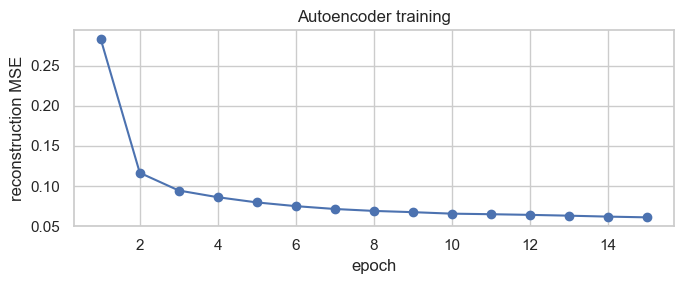

In [17]:
# ============================================
# CELL 17 - Train the autoencoder
# ============================================

if CONFIG["run_autoencoder"]:
    set_seed()
    autoencoder = ConvAutoencoder(CONFIG["embedding_dim"]).to(DEVICE)
    optimizer = torch.optim.AdamW(autoencoder.parameters(), lr=CONFIG["learning_rate"])
    loader = make_gallery_loader(shuffle=True)

    ae_history = []
    start = time.time()
    for epoch in range(CONFIG["autoencoder_epochs"]):
        autoencoder.train()
        total, seen = 0.0, 0
        for images, _ in loader:
            images = images.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            reconstruction, _ = autoencoder(images)
            loss = F.mse_loss(reconstruction, images)
            loss.backward()
            optimizer.step()
            total += loss.item() * images.size(0)
            seen += images.size(0)
        ae_history.append(total / seen)
        print(f"[autoencoder] epoch {epoch + 1}/{CONFIG['autoencoder_epochs']} "
              f"MSE {ae_history[-1]:.5f}")
    print(f"Trained in {(time.time() - start) / 60:.1f} min")

    plt.figure(figsize=(7, 3))
    plt.plot(range(1, len(ae_history) + 1), ae_history, marker="o")
    plt.xlabel("epoch"); plt.ylabel("reconstruction MSE")
    plt.title("Autoencoder training"); plt.tight_layout(); plt.show()

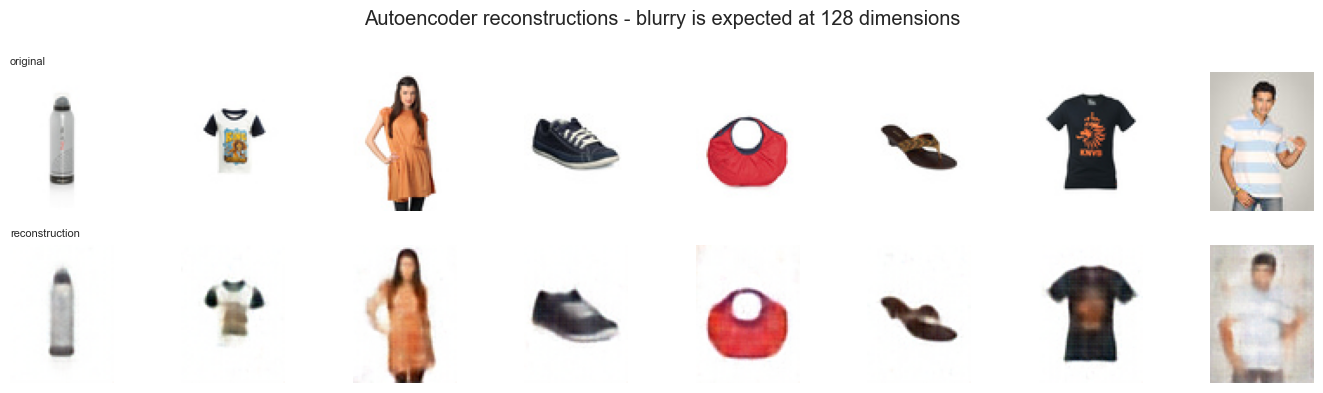

Autoencoder  P@10 = 52.36%  mAP@10 = 48.08%


In [18]:
# ============================================
# CELL 18 - Inspect reconstructions, then build the index
# ============================================

if CONFIG["run_autoencoder"]:
    autoencoder.eval()
    sample_positions = np.random.choice(len(gallery), 8, replace=False)
    batch = torch.stack([
        (torch.from_numpy(np.asarray(IMAGES[p], dtype=np.float32).transpose(2, 0, 1) / 255.0)
         - MEAN_T[0]) / STD_T[0]
        for p in sample_positions
    ]).to(DEVICE)

    with torch.no_grad():
        reconstruction, _ = autoencoder(batch)

    def denormalise(t):
        return np.clip((t.cpu() * STD_T[0] + MEAN_T[0]).permute(0, 2, 3, 1).numpy(), 0, 1)

    originals, rebuilt = denormalise(batch), denormalise(reconstruction)
    fig, axes = plt.subplots(2, 8, figsize=(14, 4))
    for i in range(8):
        axes[0, i].imshow(originals[i]); axes[0, i].axis("off")
        axes[1, i].imshow(rebuilt[i]); axes[1, i].axis("off")
    axes[0, 0].set_title("original", fontsize=8, loc="left")
    axes[1, 0].set_title("reconstruction", fontsize=8, loc="left")
    plt.suptitle("Autoencoder reconstructions - blurry is expected at 128 dimensions")
    plt.tight_layout(); plt.show()

    class AEEncoder(nn.Module):
        def __init__(self, model):
            super().__init__()
            self.model = model

        def forward(self, x):
            return self.model.encode(x)

    ae_embeddings = extract_embeddings(AEEncoder(autoencoder).to(DEVICE))
    EMBEDDINGS["Autoencoder"] = ae_embeddings
    INDEXES["Autoencoder"] = VisualSearchIndex(ae_embeddings, name="Autoencoder")

    summary, _ = evaluate_index(INDEXES["Autoencoder"], mode="standard")
    evaluate_index(INDEXES["Autoencoder"], mode="strict")
    print(f"Autoencoder  P@10 = {summary['P@10'] * 100:.2f}%  "
          f"mAP@10 = {summary['AP@10'] * 100:.2f}%")

## 9. Method 4 — Triplet metric learning

The other three methods produce embeddings as a *side effect* of some other objective. This one
optimises the retrieval objective directly.

**Triplet loss.** For an anchor image, a positive (same `articleType`) and a negative
(different `articleType`), push the anchor closer to the positive than to the negative by at
least a margin:

```
loss = max(0,  d(anchor, positive) − d(anchor, negative) + margin)
```

**Batch-hard mining.** Random triplets are mostly trivial — a shoe and a watch are already far
apart, so the loss is zero and nothing is learned. Instead each batch is built from P classes ×
K images, and within it the *hardest* positive (furthest same-class item) and *hardest*
negative (closest different-class item) are selected for every anchor. This concentrates
training on the pairs the model currently gets wrong.

Note the supervision is **weak**: `articleType` says two items are the same kind of garment,
not that they look alike. The model still has to learn appearance from pixels.

**Leakage control.** Duplicate photographs of one product would otherwise be sampled as easy
positives, so batches are constructed to avoid drawing two images of the same product.

In [19]:
# ============================================
# CELL 19 - Triplet encoder and batch sampler
# ============================================

class EmbeddingNet(nn.Module):
    """Same convolutional backbone family as Task 3, but the output is an embedding."""

    def __init__(self, embedding_dim=128, widths=(32, 64, 128, 256)):
        super().__init__()
        channels = 3
        blocks = []
        for width in widths:
            blocks.append(ConvBlock(channels, width))
            channels = width
        self.backbone = nn.Sequential(*blocks)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.project = nn.Linear(channels, embedding_dim)

    def forward(self, x):
        features = self.pool(self.backbone(x)).flatten(1)
        embedding = self.project(features)
        return F.normalize(embedding, p=2, dim=1)      # unit sphere -> cosine == dot product


class PKSampler(torch.utils.data.Sampler):
    """Yields batches of P classes x K images, avoiding duplicates of one product."""

    def __init__(self, labels, product_ids, p=16, k=8, batches_per_epoch=200, seed=RANDOM_STATE):
        self.p, self.k = p, k
        self.batches_per_epoch = batches_per_epoch
        self.rng = np.random.default_rng(seed)

        self.by_class = defaultdict(list)
        for index, label in enumerate(labels):
            self.by_class[label].append(index)
        # only classes with enough images to fill K slots
        self.classes = [c for c, items in self.by_class.items() if len(items) >= k]
        self.product_ids = np.asarray(product_ids)

    def __len__(self):
        return self.batches_per_epoch

    def __iter__(self):
        for _ in range(self.batches_per_epoch):
            batch = []
            chosen = self.rng.choice(self.classes, size=min(self.p, len(self.classes)),
                                     replace=False)
            for cls in chosen:
                candidates = self.by_class[cls]
                picked, used_products = [], set()
                for index in self.rng.permutation(candidates):
                    product = self.product_ids[index]
                    if product in used_products:
                        continue          # skip duplicate photos of the same product
                    picked.append(index)
                    used_products.add(product)
                    if len(picked) == self.k:
                        break
                while len(picked) < self.k:   # fall back if the class is thin
                    picked.append(int(self.rng.choice(candidates)))
                batch.extend(picked)
            yield batch


def batch_hard_triplet_loss(embeddings, labels, margin=0.3):
    """Hardest positive and hardest negative per anchor, within the batch."""
    distances = torch.cdist(embeddings, embeddings, p=2)
    same = labels[:, None] == labels[None, :]
    eye = torch.eye(len(labels), dtype=torch.bool, device=labels.device)

    positive_mask = same & ~eye
    negative_mask = ~same

    hardest_positive = (distances * positive_mask).max(dim=1).values
    masked = distances + (~negative_mask).float() * 1e6
    hardest_negative = masked.min(dim=1).values

    valid = positive_mask.any(dim=1) & negative_mask.any(dim=1)
    loss = F.relu(hardest_positive - hardest_negative + margin)
    return loss[valid].mean() if valid.any() else loss.sum() * 0.0


print("Triplet components ready.")

Triplet components ready.


Classes usable for sampling: 96 of 124 (need >= 8 images)
[triplet] epoch 1/30 loss 0.3113
[triplet] epoch 2/30 loss 0.3003
[triplet] epoch 3/30 loss 0.2997
[triplet] epoch 4/30 loss 0.2992
[triplet] epoch 5/30 loss 0.2978
[triplet] epoch 6/30 loss 0.2945
[triplet] epoch 7/30 loss 0.2886
[triplet] epoch 8/30 loss 0.2712
[triplet] epoch 9/30 loss 0.2412
[triplet] epoch 10/30 loss 0.2027
[triplet] epoch 11/30 loss 0.1628
[triplet] epoch 12/30 loss 0.1474
[triplet] epoch 13/30 loss 0.1247
[triplet] epoch 14/30 loss 0.1122
[triplet] epoch 15/30 loss 0.1010
[triplet] epoch 16/30 loss 0.0948
[triplet] epoch 17/30 loss 0.0882
[triplet] epoch 18/30 loss 0.0766
[triplet] epoch 19/30 loss 0.0696
[triplet] epoch 20/30 loss 0.0642
[triplet] epoch 21/30 loss 0.0622
[triplet] epoch 22/30 loss 0.0516
[triplet] epoch 23/30 loss 0.0514
[triplet] epoch 24/30 loss 0.0467
[triplet] epoch 25/30 loss 0.0489
[triplet] epoch 26/30 loss 0.0391
[triplet] epoch 27/30 loss 0.0393
[triplet] epoch 28/30 loss 0.0427

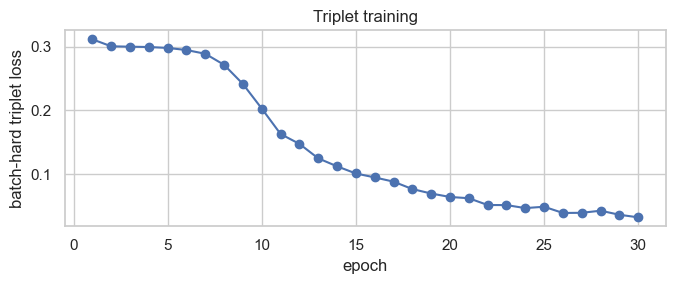

In [20]:
# ============================================
# CELL 20 - Train the triplet model
# ============================================

if CONFIG["run_triplet"]:
    set_seed()

    triplet_labels = pd.factorize(gallery[RELEVANCE_COL])[0]
    product_ids = pd.factorize(gallery["productDisplayName"].fillna(
        gallery["id"].astype(str)))[0]

    sampler = PKSampler(triplet_labels, product_ids, p=16, k=8, batches_per_epoch=200)
    print(f"Classes usable for sampling: {len(sampler.classes)} of "
          f"{len(set(triplet_labels))} (need >= 8 images)")

    triplet_loader = DataLoader(
        GalleryDataset(IMAGES, np.arange(len(gallery)), triplet_labels),
        batch_sampler=sampler,
        num_workers=CONFIG["num_workers"],
        pin_memory=(DEVICE.type == "cuda"),
    )

    triplet_model = EmbeddingNet(CONFIG["embedding_dim"]).to(DEVICE)
    optimizer = torch.optim.AdamW(triplet_model.parameters(), lr=CONFIG["learning_rate"],
                                  weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=CONFIG["triplet_epochs"])

    triplet_history = []
    start = time.time()
    for epoch in range(CONFIG["triplet_epochs"]):
        triplet_model.train()
        total, batches = 0.0, 0
        for images, labels in triplet_loader:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            embeddings = triplet_model(images)
            loss = batch_hard_triplet_loss(embeddings, labels, CONFIG["triplet_margin"])
            loss.backward()
            optimizer.step()

            total += loss.item()
            batches += 1
        scheduler.step()
        triplet_history.append(total / max(batches, 1))
        print(f"[triplet] epoch {epoch + 1}/{CONFIG['triplet_epochs']} "
              f"loss {triplet_history[-1]:.4f}")
    print(f"Trained in {(time.time() - start) / 60:.1f} min")

    plt.figure(figsize=(7, 3))
    plt.plot(range(1, len(triplet_history) + 1), triplet_history, marker="o")
    plt.xlabel("epoch"); plt.ylabel("batch-hard triplet loss")
    plt.title("Triplet training"); plt.tight_layout(); plt.show()

In [21]:
# ============================================
# CELL 21 - Build the triplet index
# ============================================

if CONFIG["run_triplet"]:
    triplet_embeddings = extract_embeddings(triplet_model)
    EMBEDDINGS["Triplet"] = triplet_embeddings
    INDEXES["Triplet"] = VisualSearchIndex(triplet_embeddings, name="Triplet")

    summary, _ = evaluate_index(INDEXES["Triplet"], mode="standard")
    evaluate_index(INDEXES["Triplet"], mode="strict")
    print(f"Triplet  P@10 = {summary['P@10'] * 100:.2f}%  "
          f"mAP@10 = {summary['AP@10'] * 100:.2f}%")

Triplet  P@10 = 92.40%  mAP@10 = 91.63%


## 10. Comparison

Both evaluation modes are reported. The gap between them quantifies how much of a method's
score comes from retrieving duplicate photographs of the same product rather than genuinely
similar different products.

In [22]:
# ============================================
# CELL 22 - Results across all methods
# ============================================

print("=" * 72)
print("STANDARD MODE - only the query itself is excluded")
print("=" * 72)
standard_table = results_table("standard")
display(standard_table)

print("=" * 72)
print("STRICT MODE - all photos of the query's product are excluded")
print("=" * 72)
strict_table = results_table("strict")
display(strict_table)

k = CONFIG["top_k"]
gap = standard_table[["Method", f"P@{k}"]].merge(
    strict_table[["Method", f"P@{k}"]], on="Method", suffixes=("_standard", "_strict"))
gap["Drop"] = (gap[f"P@{k}_standard"] - gap[f"P@{k}_strict"]).round(2)
print("How much of each score depends on duplicate product photos:")
display(gap)

STANDARD MODE - only the query itself is excluded


,Method,Dim,P@1,P@10,mAP@10,nDCG@10,R-prec,ms/query
3,Triplet,128,94.40,92.40,91.63,96.07,92.89,0.17
2,Autoencoder,128,68.75,52.36,48.08,70.35,48.10,0.17
0,Classical,236,67.75,51.37,46.66,69.93,47.08,0.22
1,Task3-CNN,384,59.30,43.96,39.05,62.56,39.75,0.18


STRICT MODE - all photos of the query's product are excluded


,Method,Dim,P@1,P@10,mAP@10,nDCG@10,R-prec,ms/query
3,Triplet,128,94.35,92.33,91.54,96.02,92.70,0.15
2,Autoencoder,128,65.50,49.79,45.40,68.60,45.80,0.19
0,Classical,236,64.30,48.94,44.00,68.19,44.95,0.16
1,Task3-CNN,384,55.55,41.83,36.94,60.74,37.95,0.23


How much of each score depends on duplicate product photos:


,Method,P@10_standard,P@10_strict,Drop
0,Triplet,92.40,92.33,0.07
1,Autoencoder,52.36,49.79,2.57
2,Classical,51.37,48.94,2.43
3,Task3-CNN,43.96,41.83,2.13


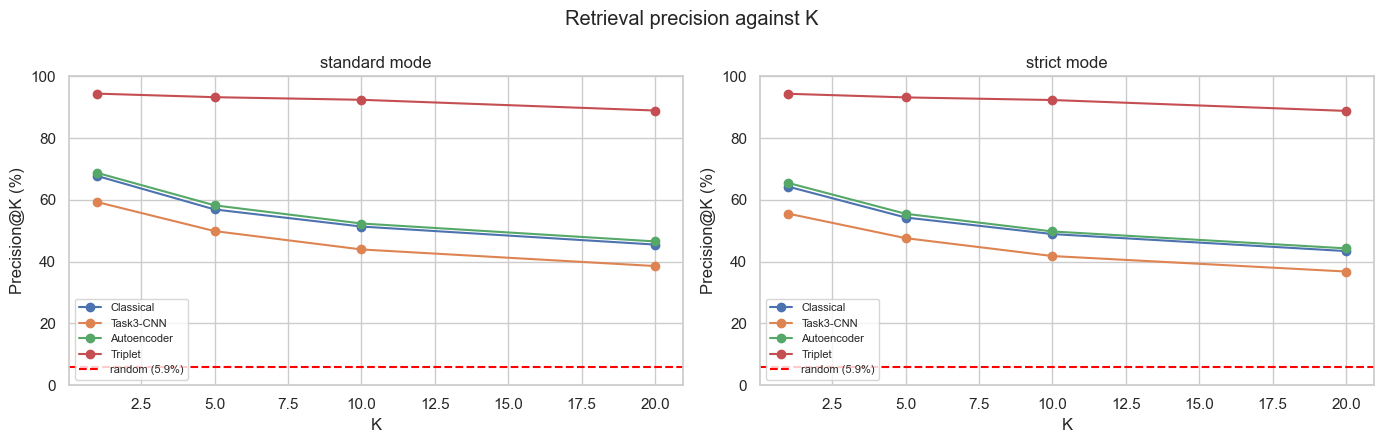

In [23]:
# ============================================
# CELL 23 - Precision at K curves
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, mode in zip(axes, ["standard", "strict"]):
    for name, modes in RESULTS.items():
        if mode not in modes:
            continue
        values = [modes[mode][f"P@{k}"] * 100 for k in CONFIG["k_values"]]
        ax.plot(CONFIG["k_values"], values, marker="o", label=name)

    # random-retrieval floor
    floor = (class_counts / len(gallery) * class_counts).sum() / len(gallery) * 100
    ax.axhline(floor, ls="--", color="red", label=f"random ({floor:.1f}%)")
    ax.set_xlabel("K"); ax.set_ylabel("Precision@K (%)")
    ax.set_title(f"{mode} mode"); ax.legend(fontsize=8); ax.set_ylim(0, 100)
plt.suptitle("Retrieval precision against K")
plt.tight_layout(); plt.show()

In [24]:
# ============================================
# CELL 24 - What makes a query hard?
# ============================================

BEST_METHOD = results_table("strict").iloc[0]["Method"]
print("Best method by strict P@10:", BEST_METHOD)

_, ranked = evaluate_index(INDEXES[BEST_METHOD], mode="strict", store=False)

per_query = []
confusions = defaultdict(Counter)
for i, q in enumerate(query_positions):
    top = ranked[i][:CONFIG["top_k"]]
    hits = binary_relevance(q, top)
    per_query.append({
        "articleType": article[q],
        "P@10": hits.mean(),
        "class_size": int(class_counts[article[q]]),
    })
    for position, hit in zip(top, hits):
        if not hit:
            confusions[article[q]][article[position]] += 1
per_query = pd.DataFrame(per_query)

by_class = (per_query.groupby("articleType")
            .agg(Queries=("P@10", "size"), MeanP10=("P@10", "mean"),
                 ClassSize=("class_size", "first"))
            .sort_values("MeanP10", ascending=False))
by_class["MeanP10"] = (by_class["MeanP10"] * 100).round(1)

reliable = by_class[by_class["Queries"] >= 5]
print("\nEasiest classes to retrieve:")
display(reliable.head(10))
print("Hardest classes to retrieve:")
display(reliable.tail(10))

Best method by strict P@10: Triplet

Easiest classes to retrieve:


,Queries,MeanP10,ClassSize
articleType,,,
Accessory Gift Set,23,100.0,106
Backpacks,24,100.0,710
Bangle,24,100.0,58
Bra,23,100.0,297
Basketballs,8,100.0,13
Belts,26,100.0,795
Booties,12,100.0,12
Caps,22,100.0,274
Churidar,17,100.0,30


Hardest classes to retrieve:


,Queries,MeanP10,ClassSize
articleType,,,
Sports Shoes,28,78.6,1991
Free Gifts,26,78.1,69
Tights,5,78.0,9
Heels,25,73.2,1048
Casual Shoes,28,70.4,2683
Clothing Set,5,70.0,8
Footballs,5,70.0,8
Tops,25,64.4,1614
Lip Gloss,5,44.0,6


Spearman correlation between class size and P@10: -0.385 (weak negative)
NEGATIVE: larger classes are HARDER, the opposite of the naive expectation.
The large classes here are apparel with shared silhouettes, while the
small ones are distinctive accessories. Rarity is not the constraint.


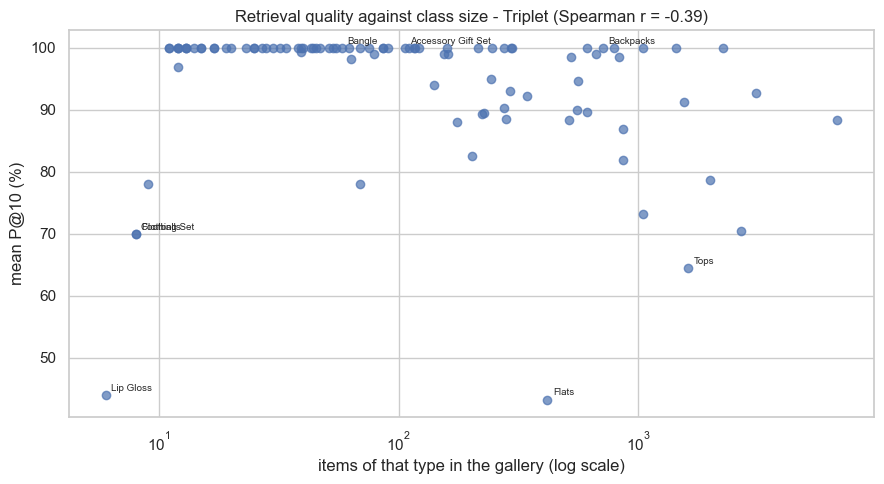


LARGE classes that are still hard - difficulty here cannot be rarity:


,Queries,MeanP10,ClassSize
articleType,,,
Flats,28,43.2,418


What each of them gets confused with:
  Flats            -> Heels (141), Flip Flops (13), Casual Shoes (5)

These are garments that are genuinely similar in a 60x80 catalogue photo:
tops, tunics, kurtis and t-shirts share a silhouette, and the distinction
is often fabric, length or styling rather than shape. Watches, belts and
sunglasses score near 100% because nothing else in the catalogue looks
like them. Visual confusability, not class size, is the limiting factor.


In [25]:
# ============================================
# CELL 24b - Class size does NOT explain difficulty
# ============================================

correlation = reliable[["ClassSize", "MeanP10"]].corr(method="spearman").iloc[0, 1]
strength = ("negligible" if abs(correlation) < 0.20 else
            "weak" if abs(correlation) < 0.40 else
            "moderate" if abs(correlation) < 0.60 else "strong")
direction = "negative" if correlation < 0 else "positive"

print(f"Spearman correlation between class size and P@10: {correlation:+.3f} "
      f"({strength} {direction})")

if correlation < -0.2:
    print("NEGATIVE: larger classes are HARDER, the opposite of the naive expectation.")
    print("The large classes here are apparel with shared silhouettes, while the")
    print("small ones are distinctive accessories. Rarity is not the constraint.")
elif correlation > 0.2:
    print("POSITIVE: larger classes are easier, consistent with more relevant items")
    print("being available to retrieve.")
else:
    print("Class size explains almost none of the variation in retrieval quality.")

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(reliable["ClassSize"], reliable["MeanP10"], alpha=0.7)
for name in list(reliable.index[:3]) + list(reliable.index[-5:]):
    row = reliable.loc[name]
    ax.annotate(name, (row["ClassSize"], row["MeanP10"]), fontsize=7,
                xytext=(4, 3), textcoords="offset points")
ax.set_xscale("log")
ax.set_xlabel("items of that type in the gallery (log scale)")
ax.set_ylabel("mean P@10 (%)")
ax.set_title(f"Retrieval quality against class size - {BEST_METHOD} "
             f"(Spearman r = {correlation:.2f})")
plt.tight_layout(); plt.show()

# Large classes that still perform badly - these isolate visual confusability
hard_but_common = reliable[(reliable["ClassSize"] > 150) & (reliable["MeanP10"] < 60)]
print("\nLARGE classes that are still hard - difficulty here cannot be rarity:")
display(hard_but_common)

print("What each of them gets confused with:")
for name in hard_but_common.index[:5]:
    top_confusions = confusions[name].most_common(4)
    formatted = ", ".join(f"{other} ({count})" for other, count in top_confusions)
    print(f"  {name:16s} -> {formatted}")

print()
print("These are garments that are genuinely similar in a 60x80 catalogue photo:")
print("tops, tunics, kurtis and t-shirts share a silhouette, and the distinction")
print("is often fabric, length or styling rather than shape. Watches, belts and")
print("sunglasses score near 100% because nothing else in the catalogue looks")
print("like them. Visual confusability, not class size, is the limiting factor.")

## 10b. Control evaluation — an attribute the Triplet model never saw

The comparison so far has a structural flaw. Relevance is defined as *sharing `articleType`*,
and the Triplet model was **trained on `articleType`**. It was optimised for the exact quantity
it is being scored on, while the classical descriptor and the autoencoder never saw any label,
and the Task 3 CNN only saw `gender` and `usage`.

The fix is to re-score every method against a **control attribute**
(`CONFIG["relevance_control"]`, default `baseColour`) that no method was trained on. This puts
all four on equal footing.

Read it this way:

* Triplet still winning ⇒ it learned a genuinely better visual space, not just its training label.
* Triplet's lead collapsing ⇒ its advantage under `articleType` was largely the circularity, and
  the report must say so.

Control attribute: baseColour (47 values)
No method in this notebook was trained on it.


,Method,P@10 (articleType),P@10 (baseColour),vs random
2,Autoencoder,49.79,26.55,2.6
0,Classical,48.94,23.56,2.3
1,Task3-CNN,41.83,19.84,1.9
3,Triplet,92.33,18.63,1.8


Random floor for baseColour: 10.40%

Winner on articleType (trained attribute): Triplet
Winner on baseColour (control attribute)   : Autoencoder

The ranking changes on the control attribute. Report this: the lead under
articleType is at least partly because that method was trained on it.


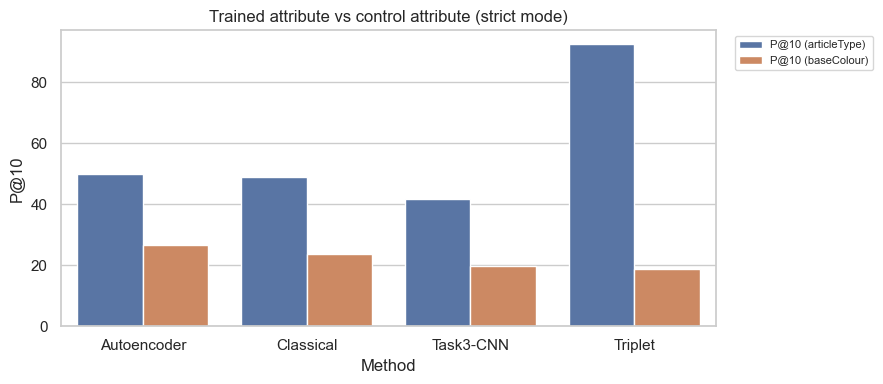

In [26]:
# ============================================
# CELL 24c - Re-score every method on the control attribute
# ============================================

CONTROL_COL = CONFIG["relevance_control"]
control_values = gallery[CONTROL_COL].fillna("Unknown").to_numpy()
control_counts = pd.Series(control_values).value_counts()

print(f"Control attribute: {CONTROL_COL} ({len(control_counts)} values)")
print("No method in this notebook was trained on it.")


def control_precision(index, k=None, mode="strict"):
    """Precision@K where a hit shares the CONTROL attribute instead."""
    k = k or CONFIG["top_k"]
    exclude = exclude_strict if mode == "strict" else exclude_standard
    _, ranked = index.search(index.vectors[query_positions], k=k, exclude=exclude)
    scores = [
        (control_values[ranked[i][:k]] == control_values[q]).mean()
        for i, q in enumerate(query_positions)
    ]
    return float(np.mean(scores)) * 100


control_rows = []
for name, index in INDEXES.items():
    control_rows.append({
        "Method": name,
        f"P@10 ({RELEVANCE_COL})": round(RESULTS[name]["strict"]["P@10"] * 100, 2),
        f"P@10 ({CONTROL_COL})": round(control_precision(index), 2),
    })

control_table = pd.DataFrame(control_rows).sort_values(
    f"P@10 ({CONTROL_COL})", ascending=False)

# random floor for the control attribute
control_floor = (control_counts / len(gallery) * control_counts).sum() / len(gallery) * 100
control_table["vs random"] = (control_table[f"P@10 ({CONTROL_COL})"]
                              / control_floor).round(1)
display(control_table)
print(f"Random floor for {CONTROL_COL}: {control_floor:.2f}%")

trained_winner = control_table.sort_values(
    f"P@10 ({RELEVANCE_COL})", ascending=False).iloc[0]["Method"]
control_winner = control_table.iloc[0]["Method"]
print(f"\nWinner on {RELEVANCE_COL} (trained attribute): {trained_winner}")
print(f"Winner on {CONTROL_COL} (control attribute)   : {control_winner}")
if trained_winner == control_winner:
    print("\nThe same method wins on an attribute it was never trained for, so its")
    print("advantage reflects a better embedding space rather than the circularity.")
else:
    print("\nThe ranking changes on the control attribute. Report this: the lead under")
    print(f"{RELEVANCE_COL} is at least partly because that method was trained on it.")

fig, ax = plt.subplots(figsize=(9, 4))
plot_data = control_table.melt(id_vars="Method",
                               value_vars=[f"P@10 ({RELEVANCE_COL})",
                                           f"P@10 ({CONTROL_COL})"],
                               var_name="Relevance", value_name="P@10")
sns.barplot(data=plot_data, x="Method", y="P@10", hue="Relevance", ax=ax)
ax.set_title("Trained attribute vs control attribute (strict mode)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()

control_table.to_csv(ARTIFACT_DIR / "control_attribute_comparison.csv", index=False)

## 10c. Rebuilding for the real use case

Everything above shares a flaw that only matters once the deployment scenario is stated
plainly: **a user uploads a photograph that is not in the catalogue, and the system returns
similar catalogue items.**

Two problems with the protocol so far:

1. **The learned encoders were trained on the entire gallery**, and the queries were drawn from
   that same gallery. Every query image was part of training. That is the retrieval equivalent
   of testing on the training set, and it flatters the autoencoder and the triplet model while
   leaving the classical descriptor unaffected.
2. **The triplet model was supervised on `articleType` alone**, and section 10b showed the cost:
   it discards colour, dropping to third place on `baseColour`. A shopper asking for "something
   like this" cares about colour, so the deployed system should not have thrown it away.

This section fixes both, then measures whether the fixes help.

**New protocol.** Whole *products* are held out (not rows), so no photograph of a held-out
product appears anywhere in training or in the catalogue index. Held-out images act as the
"user upload"; the catalogue is the remaining items. Grouping by product also removes the
duplicate-photo issue entirely — there is no strict/standard distinction left to make.

**Four changes tested, each measurable:**

| Change | Intended effect |
|---|---|
| Train on the catalogue split only | honest measurement, no leakage |
| Auxiliary colour + type classification losses | keep colour in the embedding |
| Flip and photometric augmentation | robustness to a user's photo |
| Test-time augmentation, fusion, colour re-ranking | cheap gains at query time |

In [27]:
# ============================================
# CELL 24d - Product-level held-out split
# ============================================

set_seed()
rng = np.random.default_rng(RANDOM_STATE)

# Group by product so every photograph of a held-out item is held out together.
product_key = gallery["productDisplayName"].fillna(gallery["id"].astype(str)).to_numpy()
unique_products = np.unique(product_key)
rng.shuffle(unique_products)

n_holdout = int(len(unique_products) * CONFIG["holdout_fraction"])
holdout_products = set(unique_products[:n_holdout])

is_holdout = np.array([p in holdout_products for p in product_key])
CATALOGUE_POS = np.where(~is_holdout)[0]     # the searchable catalogue + training data
HELDOUT_POS = np.where(is_holdout)[0]        # stand-ins for "user uploads"

print(f"Products: {len(unique_products)} -> {len(holdout_products)} held out")
print(f"Catalogue (index + training): {len(CATALOGUE_POS):,} images")
print(f"Held-out queries available  : {len(HELDOUT_POS):,} images")

# no product appears on both sides
assert not (set(product_key[CATALOGUE_POS]) & set(product_key[HELDOUT_POS])), \
    "Product leaked across the split"

# every query must have at least one same-type item to find in the catalogue
catalogue_types = pd.Series(article[CATALOGUE_POS]).value_counts()
usable = np.array([article[p] in catalogue_types.index for p in HELDOUT_POS])
print(f"Held-out images whose type exists in the catalogue: {usable.sum():,} "
      f"({usable.mean() * 100:.1f}%)")

HELDOUT_POS = HELDOUT_POS[usable]
if len(HELDOUT_POS) > CONFIG["n_queries"]:
    HELDOUT_QUERIES = np.sort(rng.choice(HELDOUT_POS, CONFIG["n_queries"], replace=False))
else:
    HELDOUT_QUERIES = np.sort(HELDOUT_POS)
print(f"Query set for this section: {len(HELDOUT_QUERIES):,} unseen images")

Products: 27553 -> 4132 held out
Catalogue (index + training): 32,837 images
Held-out queries available  : 5,775 images
Held-out images whose type exists in the catalogue: 5,774 (100.0%)
Query set for this section: 2,000 unseen images


In [28]:
# ============================================
# CELL 24e - Catalogue-only index and the deployment metric
# ============================================

colour_values = gallery["baseColour"].fillna("Unknown").to_numpy()


class CatalogueIndex(VisualSearchIndex):
    """Searches only the catalogue split and returns GALLERY positions."""

    def __init__(self, embeddings, name="index", catalogue=None):
        self.catalogue = CATALOGUE_POS if catalogue is None else catalogue
        super().__init__(np.asarray(embeddings)[self.catalogue], name=name)

    def search(self, query_vectors, k=10, exclude=None, batch_size=512):
        scores, local = super().search(query_vectors, k=k, exclude=None,
                                       batch_size=batch_size)
        return scores, self.catalogue[local]


def evaluate_deployment(index, embeddings, queries=None, k_values=None, label=None):
    """Evaluate with unseen queries against the catalogue index."""
    queries = HELDOUT_QUERIES if queries is None else queries
    k_values = k_values or CONFIG["k_values"]
    k = CONFIG["top_k"]

    query_vectors = np.asarray(embeddings)[queries]
    start = time.time()
    _, ranked = index.search(query_vectors, k=max(k_values))
    elapsed = (time.time() - start) / len(queries) * 1000

    rows = [evaluate_ranking(q, ranked[i], k_values) for i, q in enumerate(queries)]
    summary = pd.DataFrame(rows).mean().to_dict()

    # Product-level metric: a result is useful when the TYPE and the COLOUR match,
    # which is much closer to what "similar item" means to a shopper.
    type_hit = np.array([[article[p] == article[q] for p in ranked[i][:k]]
                         for i, q in enumerate(queries)])
    colour_hit = np.array([[colour_values[p] == colour_values[q] for p in ranked[i][:k]]
                           for i, q in enumerate(queries)])
    summary["type@10"] = float(type_hit.mean())
    summary["colour@10"] = float(colour_hit.mean())
    summary["both@10"] = float((type_hit & colour_hit).mean())
    summary["ms_per_query"] = elapsed
    summary["dim"] = index.dim

    DEPLOY_RESULTS[label or index.name] = summary
    return summary, ranked


def deployment_table():
    rows = []
    k = CONFIG["top_k"]
    for name, s in DEPLOY_RESULTS.items():
        rows.append({
            "Method": name,
            "Dim": int(s["dim"]),
            "P@1": round(s["P@1"] * 100, 2),
            f"P@{k}": round(s[f"P@{k}"] * 100, 2),
            f"mAP@{k}": round(s[f"AP@{k}"] * 100, 2),
            "colour@10": round(s["colour@10"] * 100, 2),
            "both@10": round(s["both@10"] * 100, 2),
            "ms/query": round(s["ms_per_query"], 2),
        })
    return pd.DataFrame(rows).sort_values("both@10", ascending=False)


DEPLOY_RESULTS = {}

# Baseline: the existing methods, re-measured under the honest protocol.
for name in list(INDEXES):
    index = CatalogueIndex(EMBEDDINGS[name], name=name)
    evaluate_deployment(index, EMBEDDINGS[name], label=f"{name} (old)")

print("Existing methods re-measured with UNSEEN queries:")
display(deployment_table())
print("Autoencoder and Triplet were trained on these images, so even these numbers")
print("remain optimistic. The models trained below never see the held-out products.")

Existing methods re-measured with UNSEEN queries:


,Method,Dim,P@1,P@10,mAP@10,colour@10,both@10,ms/query
2,Autoencoder (old),128,78.40,70.28,63.73,33.12,24.06,0.04
0,Classical (old),236,77.15,68.78,62.09,30.33,22.18,0.08
3,Triplet (old),128,90.00,88.25,84.45,20.31,17.82,0.04
1,Task3-CNN (old),384,74.40,66.14,59.12,22.57,16.63,0.04


Autoencoder and Triplet were trained on these images, so even these numbers
remain optimistic. The models trained below never see the held-out products.


### The improved encoder

Three changes to the triplet recipe, each aimed at the deployment scenario rather than at the
benchmark:

**1. Auxiliary classification heads.** The embedding feeds two extra linear classifiers — one
for `articleType`, one for `baseColour` — whose losses are added to the triplet loss. The colour
head is the important one: section 10b showed that a pure `articleType` triplet actively
discards colour, and this forces the embedding to retain it. The heads are discarded at
inference, so retrieval cost is unchanged.

**2. Augmentation.** Horizontal flip plus mild brightness/contrast jitter. Task 3 found heavy
augmentation harmful for *classification* of clean catalogue photos, but here the query at
deployment time is a user's photograph with unknown lighting, so a little photometric
invariance is exactly what is wanted. Applied on the GPU, so it costs almost nothing.

**3. Trained on the catalogue split only.** No held-out product is ever seen.

In [29]:
# ============================================
# CELL 24f - GPU augmentation and the improved encoder
# ============================================

def augment_batch(x):
    """Cheap per-sample augmentation applied to an already-normalised batch."""
    if CONFIG["aug_flip"]:
        flip = torch.rand(x.size(0), device=x.device) < 0.5
        x = torch.where(flip.view(-1, 1, 1, 1), torch.flip(x, dims=[3]), x)

    jitter = CONFIG["aug_photometric"]
    if jitter > 0:
        brightness = 1.0 + (torch.rand(x.size(0), 1, 1, 1, device=x.device) * 2 - 1) * jitter
        contrast = 1.0 + (torch.rand(x.size(0), 1, 1, 1, device=x.device) * 2 - 1) * jitter
        mean = x.mean(dim=(1, 2, 3), keepdim=True)
        x = (x - mean) * contrast + mean * brightness
    return x


class ImprovedEncoder(nn.Module):
    """Embedding network with auxiliary type and colour classifiers."""

    def __init__(self, embedding_dim=128, widths=(32, 64, 128, 256),
                 n_types=0, n_colours=0):
        super().__init__()
        channels = 3
        blocks = []
        for width in widths:
            blocks.append(ConvBlock(channels, width))
            channels = width
        self.backbone = nn.Sequential(*blocks)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.project = nn.Linear(channels, embedding_dim)

        # auxiliary heads - used for training only, dropped at inference
        self.type_head = nn.Linear(embedding_dim, n_types) if n_types else None
        self.colour_head = nn.Linear(embedding_dim, n_colours) if n_colours else None

    def embed(self, x):
        features = self.pool(self.backbone(x)).flatten(1)
        return F.normalize(self.project(features), p=2, dim=1)

    def forward(self, x, with_heads=False):
        z = self.embed(x)
        if not with_heads:
            return z
        return (z,
                self.type_head(z) if self.type_head is not None else None,
                self.colour_head(z) if self.colour_head is not None else None)


type_codes, type_names = pd.factorize(gallery[RELEVANCE_COL])
colour_codes, colour_names = pd.factorize(gallery["baseColour"].fillna("Unknown"))
print(f"Auxiliary heads: {len(type_names)} types, {len(colour_names)} colours")

Auxiliary heads: 124 types, 47 colours


[improved] epoch 1/30 triplet 0.3110  type 4.6442  colour 3.1364
[improved] epoch 2/30 triplet 0.3006  type 4.5530  colour 2.9072
[improved] epoch 3/30 triplet 0.3006  type 4.5368  colour 2.9160
[improved] epoch 4/30 triplet 0.3021  type 4.5231  colour 2.8840
[improved] epoch 5/30 triplet 0.3013  type 4.4868  colour 2.9007
[improved] epoch 6/30 triplet 0.2995  type 4.4221  colour 2.8894
[improved] epoch 7/30 triplet 0.3102  type 4.2930  colour 2.8415
[improved] epoch 8/30 triplet 0.3066  type 3.7822  colour 2.5718
[improved] epoch 9/30 triplet 0.2512  type 3.1807  colour 2.3118
[improved] epoch 10/30 triplet 0.2233  type 2.7060  colour 2.0586
[improved] epoch 11/30 triplet 0.1988  type 2.3084  colour 1.8071
[improved] epoch 12/30 triplet 0.1784  type 1.9821  colour 1.5815
[improved] epoch 13/30 triplet 0.1614  type 1.7189  colour 1.4096
[improved] epoch 14/30 triplet 0.1477  type 1.4979  colour 1.2653
[improved] epoch 15/30 triplet 0.1334  type 1.3314  colour 1.1458
[improved] epoch 16

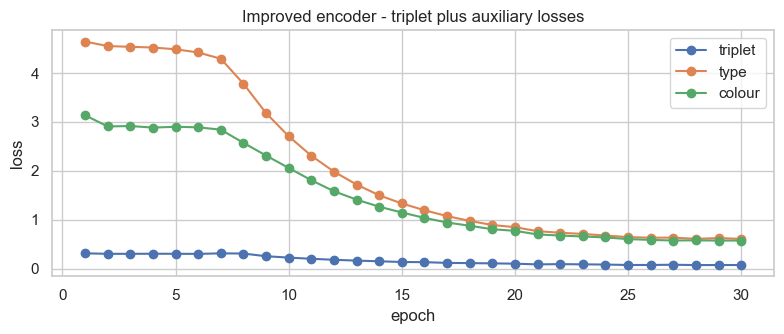

In [30]:
# ============================================
# CELL 24g - Train the improved encoder on the catalogue split
# ============================================

set_seed()

catalogue_types = type_codes[CATALOGUE_POS]
catalogue_colours = colour_codes[CATALOGUE_POS]
catalogue_products = pd.factorize(product_key[CATALOGUE_POS])[0]


class MultiLabelDataset(Dataset):
    """Returns (image, type, colour) for catalogue positions."""

    def __init__(self, positions, types, colours):
        self.positions = np.asarray(positions)
        self.types = np.asarray(types)
        self.colours = np.asarray(colours)

    def __len__(self):
        return len(self.positions)

    def __getitem__(self, index):
        array = np.asarray(IMAGES[self.positions[index]], dtype=np.float32) / 255.0
        tensor = torch.from_numpy(array.transpose(2, 0, 1))
        tensor = (tensor - MEAN_T[0]) / STD_T[0]
        return tensor, int(self.types[index]), int(self.colours[index])


sampler = PKSampler(catalogue_types, catalogue_products, p=16, k=8, batches_per_epoch=250)
improved_loader = DataLoader(
    MultiLabelDataset(CATALOGUE_POS, catalogue_types, catalogue_colours),
    batch_sampler=sampler, num_workers=CONFIG["num_workers"],
    pin_memory=(DEVICE.type == "cuda"))

improved_model = ImprovedEncoder(
    CONFIG["embedding_dim"], n_types=len(type_names), n_colours=len(colour_names)
).to(DEVICE)

optimizer = torch.optim.AdamW(improved_model.parameters(),
                              lr=CONFIG["learning_rate"], weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CONFIG["triplet_epochs"])

improved_history = []
start = time.time()
for epoch in range(CONFIG["triplet_epochs"]):
    improved_model.train()
    totals = {"triplet": 0.0, "type": 0.0, "colour": 0.0}
    batches = 0

    for images, types, colours in improved_loader:
        images = augment_batch(images.to(DEVICE, non_blocking=True))
        types = types.to(DEVICE, non_blocking=True)
        colours = colours.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        embeddings, type_logits, colour_logits = improved_model(images, with_heads=True)

        loss_triplet = batch_hard_triplet_loss(embeddings, types, CONFIG["triplet_margin"])
        loss_type = F.cross_entropy(type_logits, types)
        loss_colour = F.cross_entropy(colour_logits, colours)
        loss = (loss_triplet
                + CONFIG["aux_type_weight"] * loss_type
                + CONFIG["aux_colour_weight"] * loss_colour)

        loss.backward()
        optimizer.step()

        totals["triplet"] += loss_triplet.item()
        totals["type"] += loss_type.item()
        totals["colour"] += loss_colour.item()
        batches += 1

    scheduler.step()
    improved_history.append({k: v / max(batches, 1) for k, v in totals.items()})
    record = improved_history[-1]
    print(f"[improved] epoch {epoch + 1}/{CONFIG['triplet_epochs']} "
          f"triplet {record['triplet']:.4f}  type {record['type']:.4f}  "
          f"colour {record['colour']:.4f}")

print(f"Trained in {(time.time() - start) / 60:.1f} min")

history_df = pd.DataFrame(improved_history)
fig, ax = plt.subplots(figsize=(8, 3.5))
for column in history_df.columns:
    ax.plot(range(1, len(history_df) + 1), history_df[column], marker="o", label=column)
ax.set_xlabel("epoch"); ax.set_ylabel("loss"); ax.legend()
ax.set_title("Improved encoder - triplet plus auxiliary losses")
plt.tight_layout(); plt.show()

In [31]:
# ============================================
# CELL 24h - Embeddings with optional test-time augmentation
# ============================================

@torch.no_grad()
def embed_positions(model, positions, tta=None, batch_size=256):
    """Embed gallery positions; TTA averages the image and its mirror."""
    tta = CONFIG["use_tta"] if tta is None else tta
    model.eval()
    out = []
    for start_index in range(0, len(positions), batch_size):
        chunk = positions[start_index:start_index + batch_size]
        array = np.asarray(IMAGES[chunk], dtype=np.float32) / 255.0
        tensor = torch.from_numpy(array.transpose(0, 3, 1, 2))
        tensor = ((tensor - MEAN_T) / STD_T).to(DEVICE)

        vectors = model.embed(tensor) if hasattr(model, "embed") else model(tensor)
        if tta:
            mirrored = model.embed(torch.flip(tensor, dims=[3])) \
                if hasattr(model, "embed") else model(torch.flip(tensor, dims=[3]))
            vectors = F.normalize(vectors + mirrored, p=2, dim=1)
        out.append(vectors.float().cpu().numpy())
    return np.vstack(out)


all_positions = np.arange(len(gallery))
improved_embeddings = embed_positions(improved_model, all_positions, tta=False)
improved_embeddings_tta = embed_positions(improved_model, all_positions, tta=True)

EMBEDDINGS["Improved"] = improved_embeddings
EMBEDDINGS["Improved+TTA"] = improved_embeddings_tta

for label, vectors in [("Improved", improved_embeddings),
                       ("Improved+TTA", improved_embeddings_tta)]:
    index = CatalogueIndex(vectors, name=label)
    INDEXES[label] = index
    evaluate_deployment(index, vectors, label=label)

print("Deployment protocol - unseen queries against the catalogue:")
display(deployment_table())

Deployment protocol - unseen queries against the catalogue:


,Method,Dim,P@1,P@10,mAP@10,colour@10,both@10,ms/query
5,Improved+TTA,128,82.80,81.23,76.74,56.31,45.92,0.01
4,Improved,128,82.10,80.74,76.06,55.02,44.69,0.01
2,Autoencoder (old),128,78.40,70.28,63.73,33.12,24.06,0.04
0,Classical (old),236,77.15,68.78,62.09,30.33,22.18,0.08
3,Triplet (old),128,90.00,88.25,84.45,20.31,17.82,0.04
1,Task3-CNN (old),384,74.40,66.14,59.12,22.57,16.63,0.04


### Fusion and colour re-ranking

Two query-time additions that need no further training.

**Fusion.** Concatenate the L2-normalised learned embedding with the normalised colour
histogram, weighted. The learned vector supplies the garment type, the histogram supplies
colour fidelity that no amount of supervision recovers perfectly. A small weight sweep on the
held-out queries picks the balance.

**Re-ranking.** Retrieve a generous candidate list by embedding similarity, then re-order the
shortlist with a blended score. Re-ranking only the top 100 keeps the cost negligible while
letting an expensive-but-better criterion decide the order the user actually sees.

,colour_weight,P@10,colour@10,both@10
0,0.00,81.23,56.31,45.92
1,0.15,81.22,56.33,45.95
2,0.25,81.25,56.35,45.92
3,0.35,81.17,56.58,46.08
4,0.50,80.50,56.23,45.40


Best colour weight by both@10: 0.35


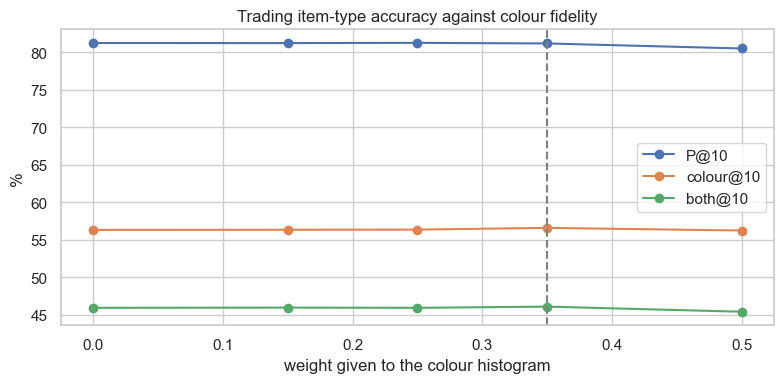

In [32]:
# ============================================
# CELL 24i - Fusion weight sweep
# ============================================

def l2(matrix):
    matrix = np.asarray(matrix, dtype=np.float32)
    return matrix / np.clip(np.linalg.norm(matrix, axis=1, keepdims=True), 1e-8, None)


colour_features = EMBEDDINGS["Classical"][:, :128]      # the HSV histogram block
learned = l2(EMBEDDINGS["Improved+TTA"])
colour_norm = l2(colour_features)

fusion_rows = []
for weight in [0.0, 0.15, 0.25, 0.35, 0.5]:
    fused = np.hstack([learned * (1 - weight), colour_norm * weight])
    index = CatalogueIndex(fused, name=f"fused_{weight}")
    summary, _ = evaluate_deployment(index, fused, label=f"Fusion w={weight}")
    fusion_rows.append({
        "colour_weight": weight,
        "P@10": round(summary["P@10"] * 100, 2),
        "colour@10": round(summary["colour@10"] * 100, 2),
        "both@10": round(summary["both@10"] * 100, 2),
    })
    # keep the table tidy - only the winner is retained afterwards
    DEPLOY_RESULTS.pop(f"Fusion w={weight}")

fusion_df = pd.DataFrame(fusion_rows)
display(fusion_df)

BEST_WEIGHT = float(fusion_df.loc[fusion_df["both@10"].idxmax(), "colour_weight"])
print(f"Best colour weight by both@10: {BEST_WEIGHT}")

fig, ax = plt.subplots(figsize=(8, 4))
for column in ["P@10", "colour@10", "both@10"]:
    ax.plot(fusion_df["colour_weight"], fusion_df[column], marker="o", label=column)
ax.axvline(BEST_WEIGHT, ls="--", color="grey")
ax.set_xlabel("weight given to the colour histogram")
ax.set_ylabel("%"); ax.legend()
ax.set_title("Trading item-type accuracy against colour fidelity")
plt.tight_layout(); plt.show()

FUSED = np.hstack([learned * (1 - BEST_WEIGHT), colour_norm * BEST_WEIGHT])
EMBEDDINGS["Fused"] = FUSED
INDEXES["Fused"] = CatalogueIndex(FUSED, name="Fused")
_ = evaluate_deployment(INDEXES["Fused"], FUSED, label="Fused")

,alpha (embedding weight),P@10,colour@10,both@10,ms/query
0,1.0,81.24,56.31,45.92,0.03
1,0.9,81.23,56.35,45.91,0.03
2,0.8,81.15,56.56,46.05,0.04
3,0.7,81.16,56.59,46.09,0.04
4,0.6,80.90,56.49,45.82,0.04
5,0.5,80.66,56.49,45.66,0.03


Best alpha by both@10: 0.7
alpha = 1.0 is the un-reranked baseline, so any gain below it comes from
the re-ranking step alone.
Registered as a deployment candidate: Improved+TTA+rerank(a=0.7)


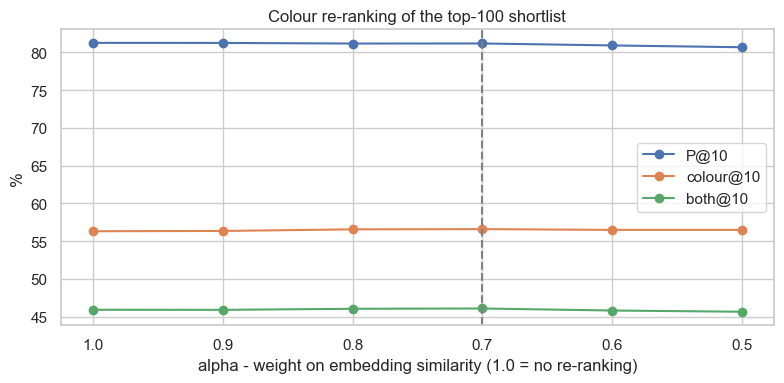

In [33]:
# ============================================
# CELL 24j - Colour-aware re-ranking of the shortlist
# ============================================

RERANK_POOL = 100


class RerankIndex:
    """Shortlist by embedding similarity, then re-order the top-N by colour.

    The stored index stays 128-dimensional; the colour criterion is applied only
    to a 100-item shortlist, so it costs far less than fusing colour into every
    vector. Query vectors arrive as [learned | colour] concatenations, which lets
    this class drop straight into every cell that expects an index.
    """

    def __init__(self, learned, colour, alpha, name="rerank", pool=RERANK_POOL,
                 catalogue=None):
        """`learned`/`colour` are gallery-sized during the experiments, but
        catalogue-sized when reloaded from disk. `catalogue` selects which:
        pass np.arange(len(learned)) for arrays that are already restricted.
        """
        self.base = CatalogueIndex(learned, name=name, catalogue=catalogue)
        colour = np.asarray(colour)
        # Align the colour table with whatever the base index indexes into.
        self.colour = l2(colour if len(colour) == len(learned) else colour)
        self.colour_by_position = (catalogue is None)
        self.split = np.asarray(learned).shape[1]
        self.alpha = alpha
        self.pool = pool
        self.name = name

    def __len__(self):
        return len(self.base)

    @property
    def dim(self):
        return self.base.dim

    @property
    def vectors(self):
        return self.base.vectors

    def search(self, query_vectors, k=10, exclude=None, batch_size=512):
        queries = np.atleast_2d(np.asarray(query_vectors, dtype=np.float32))
        learned = queries[:, :self.split]
        query_colour = l2(queries[:, self.split:])

        scores, positions = self.base.search(learned, k=max(self.pool, k))

        out_scores, out_positions = [], []
        for row in range(len(queries)):
            candidates = positions[row]
            # `candidates` are gallery positions during the experiments and row
            # indices into the saved arrays when reloaded - both index `colour`
            # correctly because it was built to match.
            colour_score = self.colour[candidates] @ query_colour[row]
            blended = self.alpha * scores[row] + (1 - self.alpha) * colour_score
            order = np.argsort(-blended)[:k]
            out_positions.append(candidates[order])
            out_scores.append(blended[order])
        return np.array(out_scores), np.array(out_positions)


# Query vectors carry both parts, so visualisation, unseen-image inference and
# saving all work without modification.
learned_all = l2(EMBEDDINGS["Improved+TTA"])
RERANK_EMBEDDINGS = np.hstack([learned_all, l2(colour_features)]).astype(np.float32)
RERANK_SPLIT = learned_all.shape[1]

rerank_rows = []
for alpha in [1.0, 0.9, 0.8, 0.7, 0.6, 0.5]:
    index = RerankIndex(learned_all, colour_features, alpha, name=f"rr{alpha}")
    summary, _ = evaluate_deployment(index, RERANK_EMBEDDINGS, label=f"_sweep_{alpha}")
    rerank_rows.append({
        "alpha (embedding weight)": alpha,
        "P@10": round(summary["P@10"] * 100, 2),
        "colour@10": round(summary["colour@10"] * 100, 2),
        "both@10": round(summary["both@10"] * 100, 2),
        "ms/query": round(summary["ms_per_query"], 2),
    })
    DEPLOY_RESULTS.pop(f"_sweep_{alpha}")

rerank_df = pd.DataFrame(rerank_rows)
display(rerank_df)

BEST_ALPHA = float(rerank_df.loc[rerank_df["both@10"].idxmax(), "alpha (embedding weight)"])
print(f"Best alpha by both@10: {BEST_ALPHA}")
print("alpha = 1.0 is the un-reranked baseline, so any gain below it comes from")
print("the re-ranking step alone.")

# Register the tuned re-ranker as a genuine deployment candidate so CELL 24k can
# choose it. It keeps a 128-dim index - half the size of the fused vector.
RERANK_LABEL = f"Improved+TTA+rerank(a={BEST_ALPHA:g})"
INDEXES[RERANK_LABEL] = RerankIndex(learned_all, colour_features, BEST_ALPHA,
                                    name=RERANK_LABEL)
EMBEDDINGS[RERANK_LABEL] = RERANK_EMBEDDINGS
_ = evaluate_deployment(INDEXES[RERANK_LABEL], RERANK_EMBEDDINGS, label=RERANK_LABEL)
print("Registered as a deployment candidate:", RERANK_LABEL)

fig, ax = plt.subplots(figsize=(8, 4))
for column in ["P@10", "colour@10", "both@10"]:
    ax.plot(rerank_df["alpha (embedding weight)"], rerank_df[column], marker="o",
            label=column)
ax.axvline(BEST_ALPHA, ls="--", color="grey")
ax.invert_xaxis()
ax.set_xlabel("alpha - weight on embedding similarity (1.0 = no re-ranking)")
ax.set_ylabel("%"); ax.legend()
ax.set_title("Colour re-ranking of the top-100 shortlist")
plt.tight_layout(); plt.show()

,Method,Dim,P@1,P@10,mAP@10,colour@10,both@10,ms/query
7,Improved+TTA+rerank(a=0.7),128,82.80,81.16,76.51,56.59,46.09,0.03
6,Fused,256,82.45,81.17,76.58,56.58,46.08,0.01
5,Improved+TTA,128,82.80,81.23,76.74,56.31,45.92,0.01
4,Improved,128,82.10,80.74,76.06,55.02,44.69,0.01
2,Autoencoder (old),128,78.40,70.28,63.73,33.12,24.06,0.04
0,Classical (old),236,77.15,68.78,62.09,30.33,22.18,0.08
3,Triplet (old),128,90.00,88.25,84.45,20.31,17.82,0.04
1,Task3-CNN (old),384,74.40,66.14,59.12,22.57,16.63,0.04



Queries: 2000 | standard error on both@10: +-1.11 points

Best raw score : Improved+TTA+rerank(a=0.7) (46.09)
Statistically tied within +-1.11:


,Method,both@10,P@10,colour@10,stored_dim,ms/query
5,Improved+TTA,45.92,81.23,56.31,128,0.01
6,Fused,46.08,81.17,56.58,256,0.01
7,Improved+TTA+rerank(a=0.7),46.09,81.16,56.59,256,0.03



Selected Improved+TTA over Improved+TTA+rerank(a=0.7): 0.17 points lower, inside the noise
floor, but cheaper to store and to serve. Same rule as the Task 3 model
selection - among candidates that cannot be distinguished, take the
simplest one.

Best previous: Autoencoder (old)   ->   deployed: Improved+TTA


,Metric,Before,After,Change,Meaningful
0,P@10,70.28,81.23,10.95,yes
1,colour@10,33.12,56.31,23.19,yes
2,both@10,24.06,45.92,21.86,yes


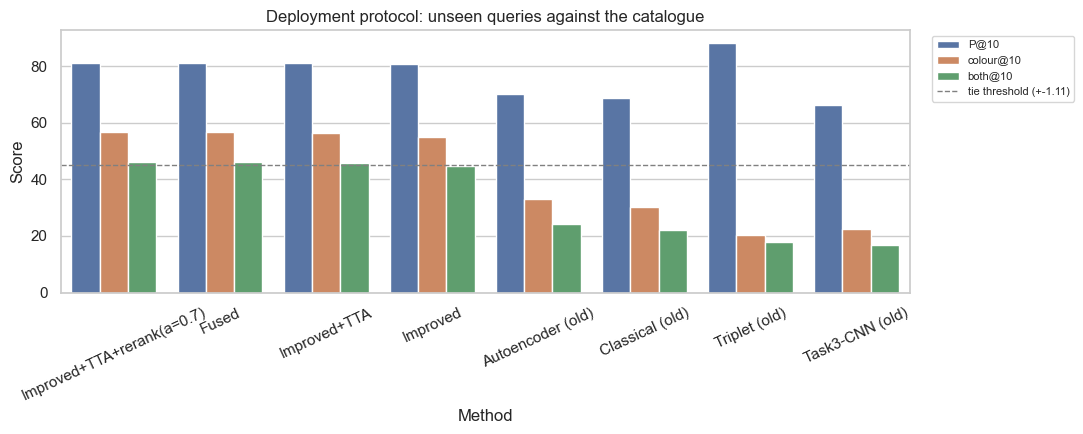


BEST METHOD FOR DEPLOYMENT: Improved+TTA
  stored dimensionality: 128
Cells 25 onwards now use this model.


In [34]:

# ============================================
# CELL 24k - Did the improvements work?
# ============================================

final_table = deployment_table()
display(final_table)

# ---- how big a difference is actually meaningful? ----------------------------
# A query set of N images gives a standard error on a proportion p of
# sqrt(p(1-p)/N). Two methods whose scores differ by less than roughly this
# amount are not distinguishable on this evidence. Successive runs of this
# notebook confirmed the need for the check: the alpha sweep selected 1.0, then
# 0.6, then 0.8 across three runs, all within a third of a point of each other.
n_queries = len(HELDOUT_QUERIES)
p_hat = final_table["both@10"].max() / 100
NOISE_FLOOR = 100 * np.sqrt(p_hat * (1 - p_hat) / n_queries)
print(f"\nQueries: {n_queries} | standard error on both@10: "
      f"+-{NOISE_FLOOR:.2f} points")

best_score = final_table["both@10"].max()
tied = final_table[final_table["both@10"] >= best_score - NOISE_FLOOR].copy()

# Among statistically tied methods, prefer the cheapest to serve: fewest stored
# numbers per item, then lowest query latency.
tied["stored_dim"] = [int(np.asarray(EMBEDDINGS[m]).shape[1]) for m in tied["Method"]]
tied = tied.sort_values(["stored_dim", "ms/query"])

print(f"\nBest raw score : {final_table.iloc[0]['Method']} ({best_score:.2f})")
print(f"Statistically tied within +-{NOISE_FLOOR:.2f}:")
display(tied[["Method", "both@10", "P@10", "colour@10", "stored_dim", "ms/query"]])

BEST_METHOD = tied.iloc[0]["Method"]

# A re-ranker at alpha = 1.0 is arithmetically identical to its base method.
if "rerank" in BEST_METHOD and abs(BEST_ALPHA - 1.0) < 1e-9:
    print(f"'{BEST_METHOD}' has alpha = 1.0, so re-ranking is a no-op.")
    BEST_METHOD = "Improved+TTA"

if BEST_METHOD != final_table.iloc[0]["Method"]:
    chosen = final_table[final_table["Method"] == BEST_METHOD].iloc[0]
    print(f"\nSelected {BEST_METHOD} over {final_table.iloc[0]['Method']}: "
          f"{best_score - chosen['both@10']:.2f} points lower, inside the noise")
    print("floor, but cheaper to store and to serve. Same rule as the Task 3 model")
    print("selection - among candidates that cannot be distinguished, take the")
    print("simplest one.")

# ---- did the improvements beat the originals? --------------------------------
old_best = final_table[final_table["Method"].str.contains(r"\(old\)")]
new_best = final_table[~final_table["Method"].str.contains(r"\(old\)")]

if len(old_best) and len(new_best):
    before = old_best.iloc[0]
    after = final_table[final_table["Method"] == BEST_METHOD].iloc[0]
    delta = pd.DataFrame([
        {"Metric": metric, "Before": before[metric], "After": after[metric],
         "Change": round(after[metric] - before[metric], 2),
         "Meaningful": "yes" if abs(after[metric] - before[metric]) > NOISE_FLOOR
                       else "within noise"}
        for metric in ["P@10", "colour@10", "both@10"]
    ])
    print(f"\nBest previous: {before['Method']}   ->   deployed: {BEST_METHOD}")
    display(delta)

fig, ax = plt.subplots(figsize=(11, 4.5))
plot_data = final_table.melt(id_vars="Method", value_vars=["P@10", "colour@10", "both@10"],
                             var_name="Metric", value_name="Score")
sns.barplot(data=plot_data, x="Method", y="Score", hue="Metric", ax=ax)
ax.axhline(best_score - NOISE_FLOOR, ls="--", color="grey", lw=1,
           label=f"tie threshold (+-{NOISE_FLOOR:.2f})")
ax.set_title("Deployment protocol: unseen queries against the catalogue")
ax.tick_params(axis="x", rotation=25)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()

final_table.to_csv(ARTIFACT_DIR / "deployment_comparison.csv", index=False)

print("\nBEST METHOD FOR DEPLOYMENT:", BEST_METHOD)
print(f"  stored dimensionality: {np.asarray(EMBEDDINGS[BEST_METHOD]).shape[1]}")
print("Cells 25 onwards now use this model.")


## 11. Looking at the results

Retrieval metrics can look healthy while the results are useless to a person, so the output has
to be inspected directly. Successes and failures are both shown — the failures are what the
report should discuss.

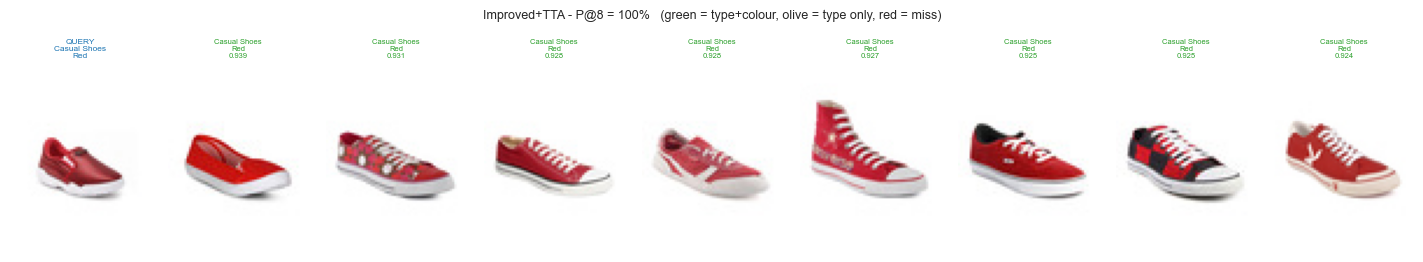

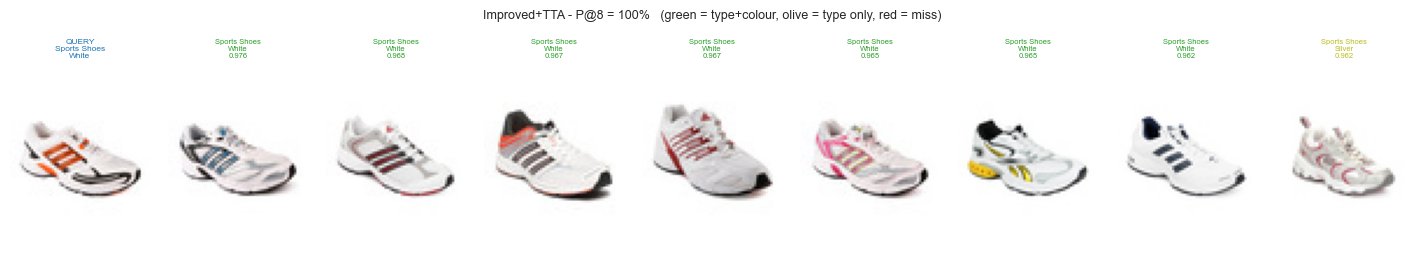

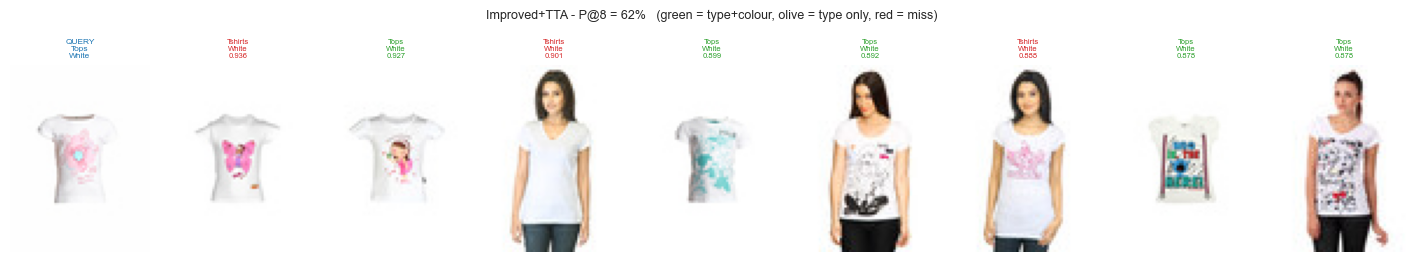

In [35]:
# ============================================
# CELL 25 - Show a query and its Top-K matches
# ============================================

def show_retrieval(method, query_position, k=8, ax_title=True):
    """Display a query and its top-K matches. Works for every index type."""
    index = INDEXES[method]
    vector = np.asarray(EMBEDDINGS[method])[query_position]

    # A CatalogueIndex never contains the query, so nothing needs excluding.
    if isinstance(index, CatalogueIndex):
        scores, positions = index.search(vector, k=k)
    else:
        same_product = name_to_positions.get(product_name[query_position], [])
        exclude = [np.unique(np.array([query_position] + list(same_product)))]
        scores, positions = index.search(vector, k=k, exclude=exclude)
    scores, positions = scores[0], positions[0]

    fig, axes = plt.subplots(1, k + 1, figsize=(1.6 * (k + 1), 2.8))
    axes[0].imshow(np.asarray(IMAGES[query_position]))
    axes[0].axis("off")
    axes[0].set_title(f"QUERY\n{article[query_position]}\n{colour_values[query_position]}",
                      fontsize=6, color="tab:blue")

    for slot, (position, score) in enumerate(zip(positions, scores), start=1):
        axes[slot].imshow(np.asarray(IMAGES[position]))
        axes[slot].axis("off")
        type_hit = article[position] == article[query_position]
        colour_hit = colour_values[position] == colour_values[query_position]
        colour = ("tab:green" if type_hit and colour_hit else
                  "tab:olive" if type_hit else "tab:red")
        axes[slot].set_title(f"{article[position]}\n{colour_values[position]}\n{score:.3f}",
                             fontsize=5.5, color=colour)
    if ax_title:
        precision = np.mean([article[p] == article[query_position] for p in positions])
        fig.suptitle(f"{method} - P@{k} = {precision * 100:.0f}%   "
                     f"(green = type+colour, olive = type only, red = miss)", fontsize=9)
    plt.tight_layout(); plt.show()


# Queries are drawn from the HELD-OUT set: images the encoder has never seen.
set_seed()
demo_queries = np.random.choice(HELDOUT_QUERIES, 3, replace=False)
for position in demo_queries:
    show_retrieval(BEST_METHOD, position, k=8)

Unseen query: Casual Shoes / Red
Footfun Kids Unisex Red Shoes



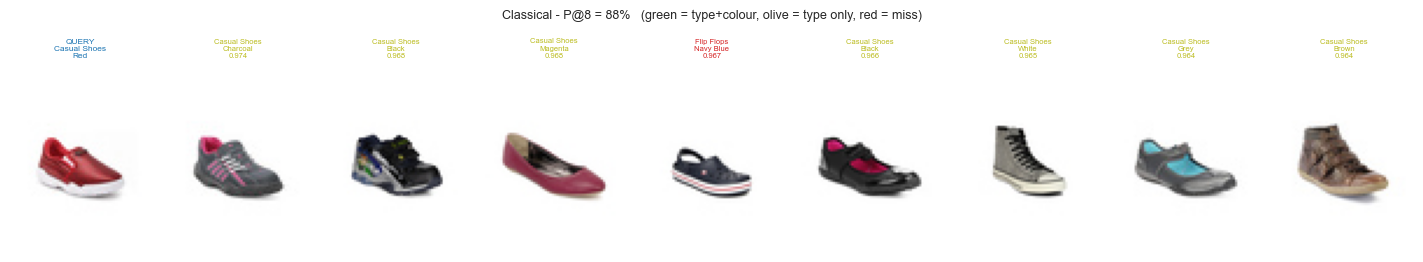

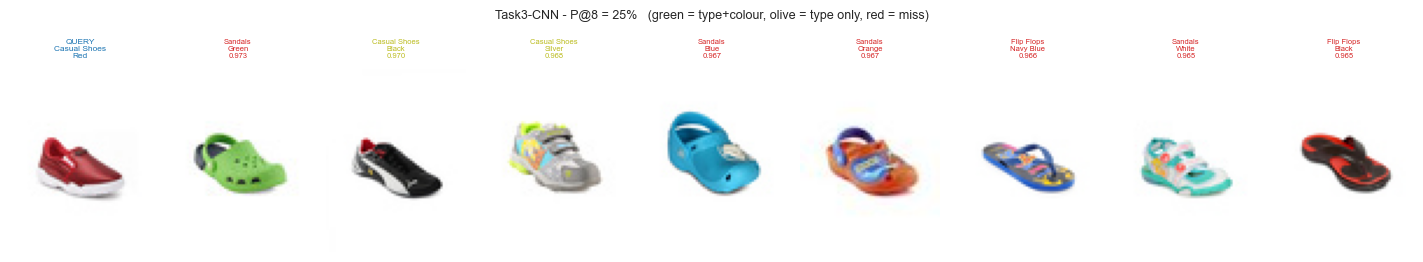

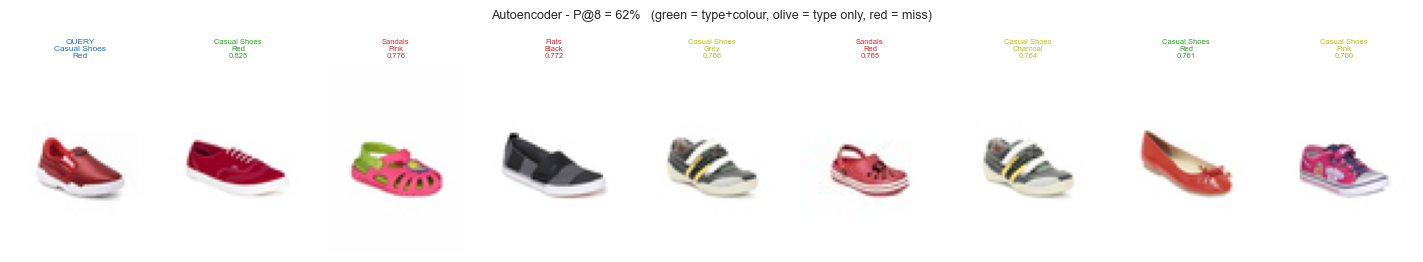

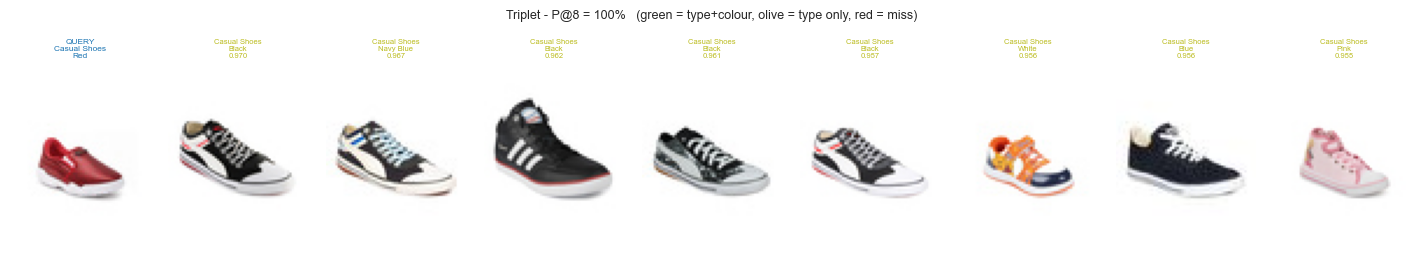

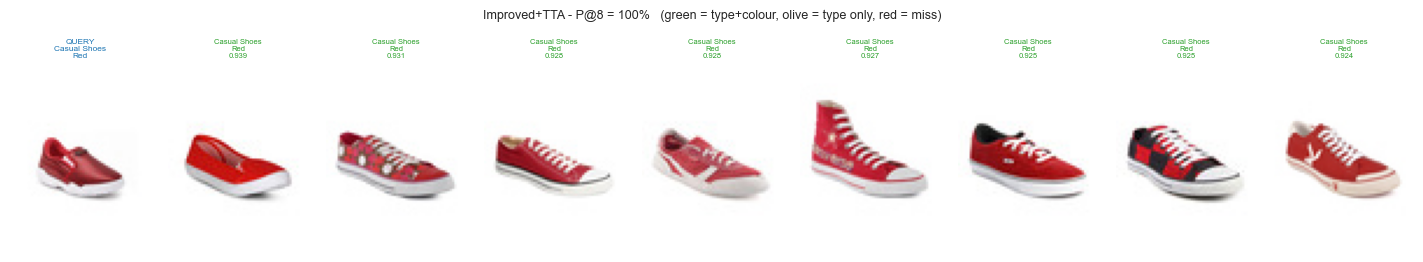

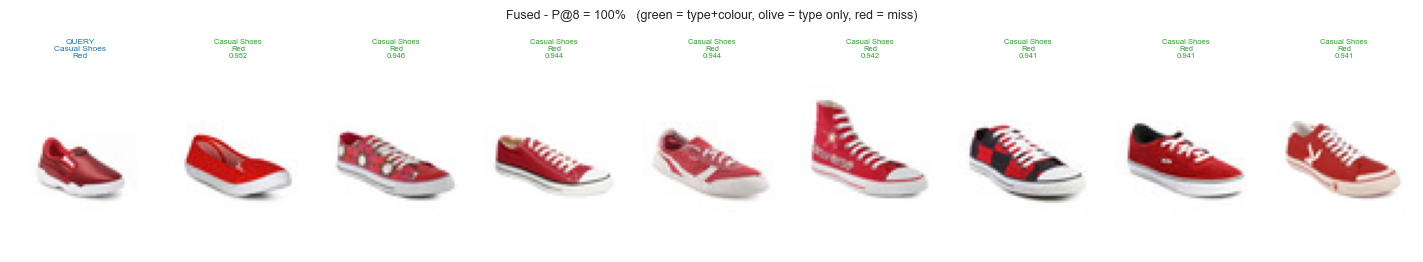

In [36]:
# ============================================
# CELL 26 - Same query, several methods side by side
# ============================================

comparison_query = demo_queries[0]
print(f"Unseen query: {article[comparison_query]} / {colour_values[comparison_query]}")
print(f"{gallery.loc[comparison_query, 'productDisplayName']}\n")

for method in ["Classical", "Task3-CNN", "Autoencoder", "Triplet",
               "Improved+TTA", "Fused"]:
    if method in INDEXES:
        show_retrieval(method, comparison_query, k=8)

Worst unseen queries for Improved+TTA:


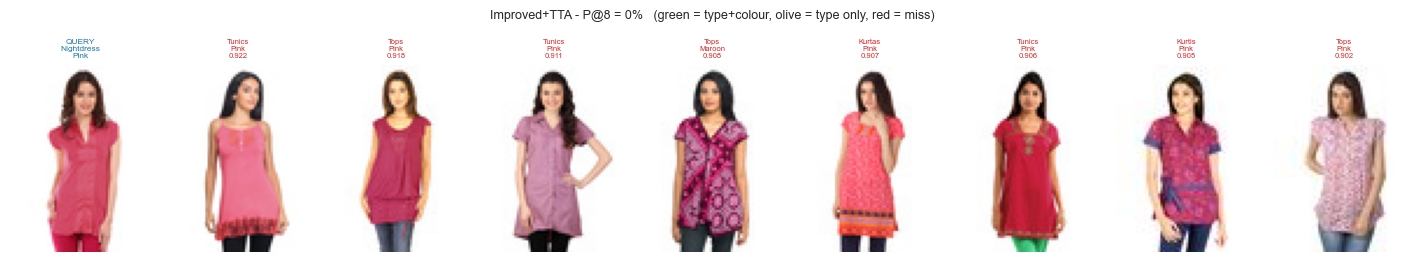

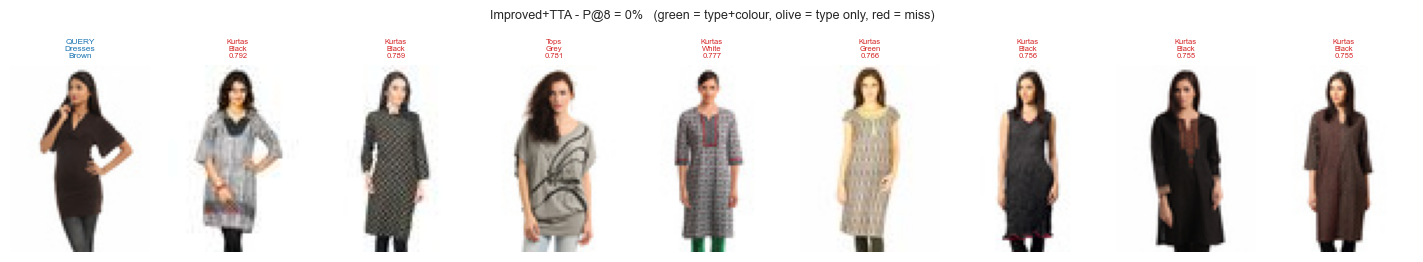

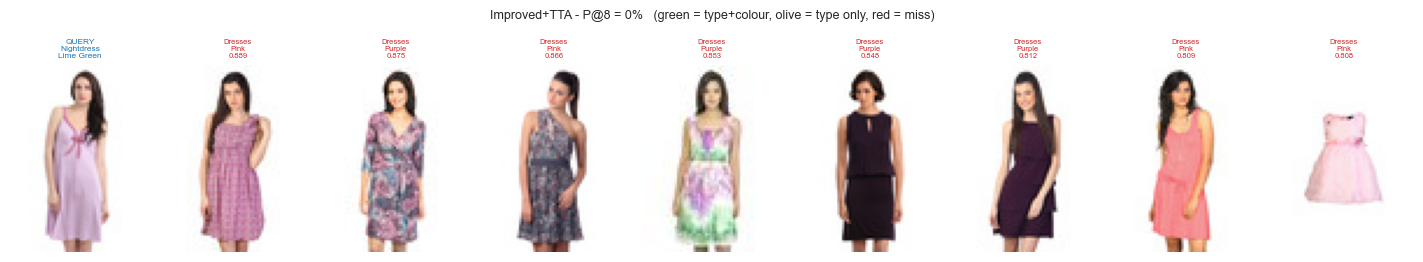

Typical causes: visually ambiguous silhouettes (tops vs tunics vs kurtis),
items photographed on a model rather than flat, and product types with few
close neighbours in the catalogue.


In [37]:
# ============================================
# CELL 27 - Failure cases on unseen queries
# ============================================

_, ranked_best = evaluate_deployment(INDEXES[BEST_METHOD], EMBEDDINGS[BEST_METHOD],
                                     label="_tmp")
DEPLOY_RESULTS.pop("_tmp", None)

k = CONFIG["top_k"]
scores = np.array([
    np.mean([article[p] == article[q] for p in ranked_best[i][:k]])
    for i, q in enumerate(HELDOUT_QUERIES)
])
worst_idx = np.argsort(scores)[:3]

print(f"Worst unseen queries for {BEST_METHOD}:")
for i in worst_idx:
    show_retrieval(BEST_METHOD, int(HELDOUT_QUERIES[i]), k=8)

print("Typical causes: visually ambiguous silhouettes (tops vs tunics vs kurtis),")
print("items photographed on a model rather than flat, and product types with few")
print("close neighbours in the catalogue.")

## 12. Is the embedding space actually organised?

t-SNE projects the high-dimensional embedding to 2D. If items of the same type form clusters,
the space has structure that nearest-neighbour search can exploit; if the projection is uniform
soup, good metrics would be suspicious.

t-SNE distances are not meaningful — only the grouping is. It is fitted on a sample for speed.

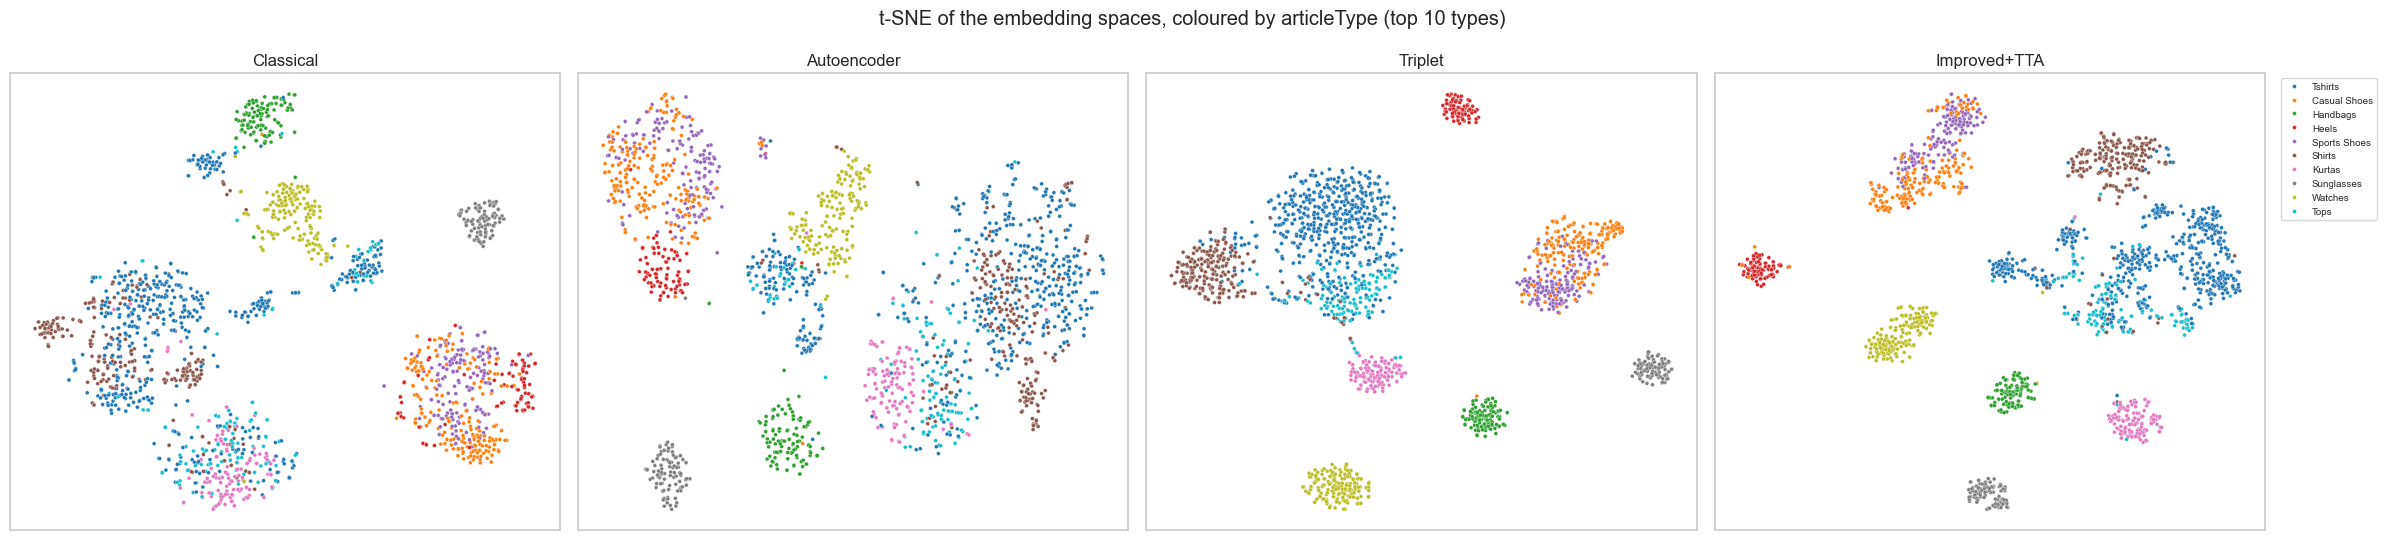

In [38]:
# ============================================
# CELL 28 - t-SNE map of the embedding spaces
# ============================================

from sklearn.manifold import TSNE

TSNE_SAMPLE = 3000
set_seed()
tsne_positions = np.random.choice(len(gallery), TSNE_SAMPLE, replace=False)
top_types = gallery["articleType"].value_counts().head(10).index
mask = gallery.loc[tsne_positions, "articleType"].isin(top_types).to_numpy()
tsne_positions = tsne_positions[mask]

show_methods = [m for m in ["Classical", "Autoencoder", "Triplet", "Improved+TTA"]
                if m in EMBEDDINGS]

fig, axes = plt.subplots(1, len(show_methods), figsize=(6 * len(show_methods), 5.5),
                         squeeze=False)
for ax, name in zip(axes[0], show_methods):
    vectors = np.asarray(EMBEDDINGS[name])[tsne_positions]
    projected = TSNE(n_components=2, perplexity=30, init="pca",
                     random_state=RANDOM_STATE).fit_transform(vectors)
    frame = pd.DataFrame({
        "x": projected[:, 0], "y": projected[:, 1],
        "articleType": gallery.loc[tsne_positions, "articleType"].to_numpy(),
    })
    sns.scatterplot(data=frame, x="x", y="y", hue="articleType", s=8, ax=ax,
                    legend=(name == show_methods[-1]), palette="tab10")
    ax.set_title(name); ax.set_xlabel(""); ax.set_ylabel("")
    ax.set_xticks([]); ax.set_yticks([])
axes[0][-1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7)
plt.suptitle("t-SNE of the embedding spaces, coloured by articleType (top 10 types)")
plt.tight_layout(); plt.show()

## 13. The realistic use case — querying with unseen images

Everything above uses gallery images as queries. The real system receives a **new** photograph
and searches the existing catalogue. The unlabelled `images_test` set provides exactly that:
5,829 images the model has never seen.

No accuracy can be computed here (no labels), so this is a qualitative demonstration plus a
latency measurement for the deployment discussion.

Unseen images available as queries: 5829
Search latency: 0.29 ms per query over 32,837 catalogue items



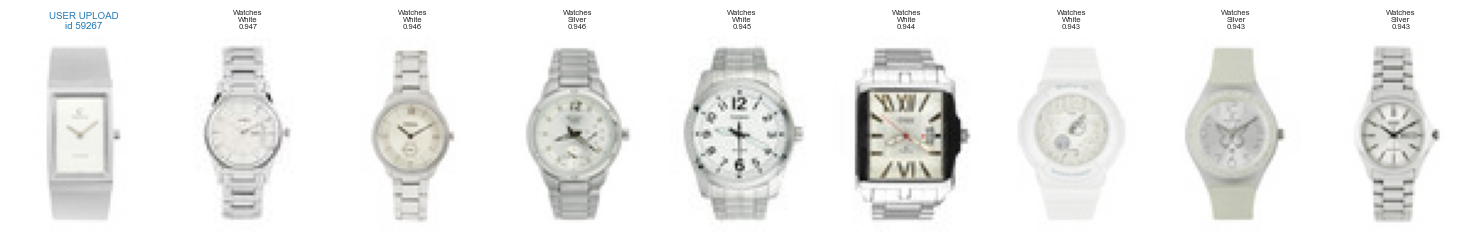

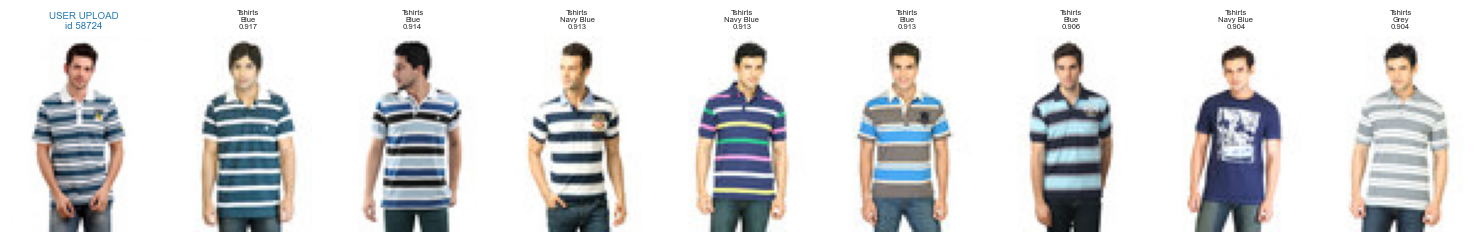

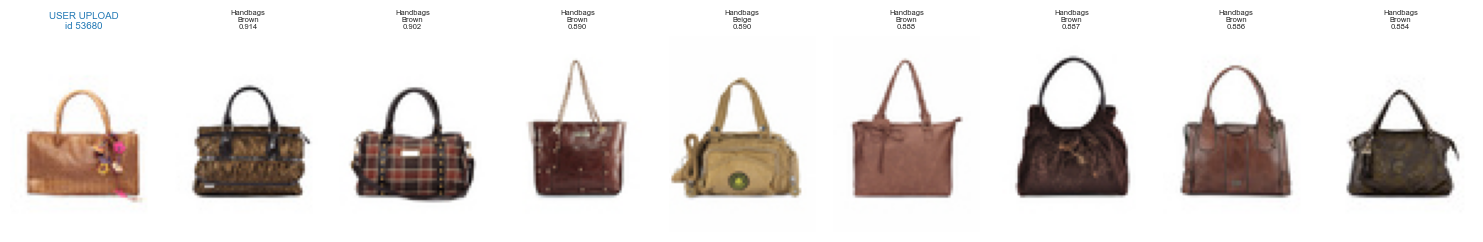

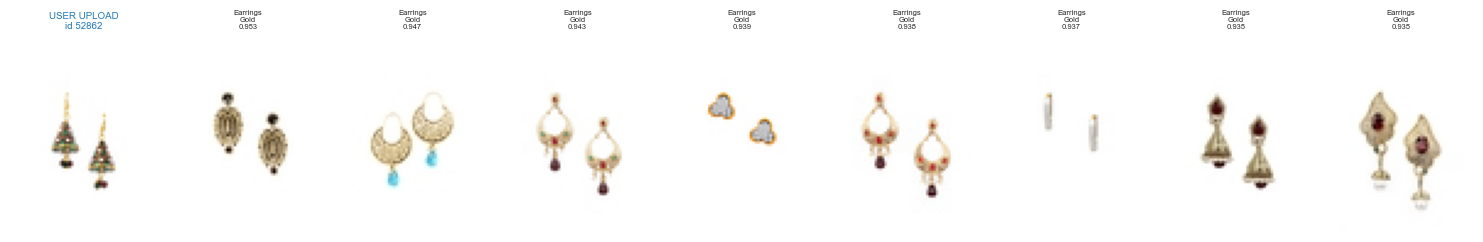

In [39]:
# ============================================
# CELL 29 - The real use case: a photo that is not in the dataset
# ============================================

test_meta = pd.read_csv(PREDICTION_METADATA)
print("Unseen images available as queries:", len(test_meta))


def embed_new_images(paths, method=None, tta=None):
    """Embed images that are NOT in the gallery - the deployment path.

    Uses exactly the pipeline the gallery embeddings were built with, so a
    user's upload is treated identically to a catalogue item.
    """
    method = method or BEST_METHOD
    tta = CONFIG["use_tta"] if tta is None else tta
    arrays = np.stack([load_image_array(p) for p in paths])

    if method == "Classical":
        return classical_features(arrays)

    tensor = torch.from_numpy(arrays.astype(np.float32).transpose(0, 3, 1, 2) / 255.0)
    tensor = ((tensor - MEAN_T) / STD_T).to(DEVICE)

    with torch.no_grad():
        if method.startswith("Improved") or method == "Fused":
            vectors = improved_model.embed(tensor)
            if tta or "TTA" in method or method == "Fused":
                mirrored = improved_model.embed(torch.flip(tensor, dims=[3]))
                vectors = F.normalize(vectors + mirrored, p=2, dim=1)
            learned_part = vectors.float().cpu().numpy()

            if "rerank" in method:
                # [learned | colour] - RerankIndex splits this internally
                colour_part = classical_features(arrays)[:, :128]
                return np.hstack([l2(learned_part), l2(colour_part)])
            if method == "Fused":
                colour_part = classical_features(arrays)[:, :128]
                return np.hstack([l2(learned_part) * (1 - BEST_WEIGHT),
                                  l2(colour_part) * BEST_WEIGHT])
            return learned_part

        if method.startswith("Task3-CNN"):
            return task3_model.features(tensor).float().cpu().numpy()
        if method.startswith("Autoencoder"):
            return autoencoder.encode(tensor).float().cpu().numpy()
        if method.startswith("Triplet"):
            return triplet_model(tensor).float().cpu().numpy()

    raise ValueError(f"Unknown method {method}")


set_seed()
sample_tests = test_meta.sample(4, random_state=RANDOM_STATE)
query_vectors = embed_new_images(sample_tests["image_path"].tolist(), BEST_METHOD)

start = time.time()
scores, positions = INDEXES[BEST_METHOD].search(query_vectors, k=8)
elapsed = (time.time() - start) / len(query_vectors) * 1000
print(f"Search latency: {elapsed:.2f} ms per query over "
      f"{len(INDEXES[BEST_METHOD]):,} catalogue items\n")

for row_index, (_, test_row) in enumerate(sample_tests.iterrows()):
    fig, axes = plt.subplots(1, 9, figsize=(15, 2.9))
    axes[0].imshow(load_image_array(test_row["image_path"]))
    axes[0].axis("off")
    axes[0].set_title(f"USER UPLOAD\nid {test_row['id']}", fontsize=7, color="tab:blue")
    for slot in range(8):
        position = positions[row_index, slot]
        axes[slot + 1].imshow(np.asarray(IMAGES[position]))
        axes[slot + 1].axis("off")
        axes[slot + 1].set_title(f"{article[position]}\n{colour_values[position]}\n"
                                 f"{scores[row_index, slot]:.3f}", fontsize=5.5)
    plt.tight_layout(); plt.show()

## 14. Save the search index

Saved as plain `.npy` plus a small JSON manifest so `app/backend/main.py` can load and serve it
without importing this notebook.

In [40]:
# ============================================
# CELL 30 - Persist the deployable index and weights
# ============================================

# Remove stale index files from earlier runs so the artefact folder is unambiguous.
for old in ARTIFACT_DIR.glob("search_index_*.npy"):
    old.unlink()
    print("Removed stale index:", old.name)

# The served index contains ONLY catalogue items - held-out products are excluded,
# exactly as a real catalogue would exclude items it does not stock.
# Take the catalogue rows of the winning embedding. For the re-ranker this is
# the [learned | colour] concatenation, which is what the backend needs to
# reproduce the shortlist-then-re-order behaviour.
catalogue_vectors = np.asarray(EMBEDDINGS[BEST_METHOD])[CATALOGUE_POS].astype(np.float32)
catalogue_ids = gallery["id"].to_numpy()[CATALOGUE_POS]

safe_name = re.sub(r"[^a-z0-9]+", "_", BEST_METHOD.lower()).strip("_")
INDEX_PATH = ARTIFACT_DIR / f"search_index_{safe_name}.npy"
np.save(INDEX_PATH, catalogue_vectors)
np.save(ARTIFACT_DIR / "gallery_ids.npy", catalogue_ids)

gallery.iloc[CATALOGUE_POS][
    ["id", "articleType", "subCategory", "masterCategory", "baseColour",
     "gender", "usage", "productDisplayName", "image_path"]
].to_csv(ARTIFACT_DIR / "gallery_metadata.csv", index=False)

torch.save({
    "state_dict": improved_model.state_dict(),
    "embedding_dim": CONFIG["embedding_dim"],
    "n_types": len(type_names),
    "n_colours": len(colour_names),
    "channel_mean": CHANNEL_MEAN.tolist(),
    "channel_std": CHANNEL_STD.tolist(),
    "image_size_pil": list(IMAGE_SIZE_PIL),
    "use_tta": CONFIG["use_tta"],
    "fusion_colour_weight": BEST_WEIGHT,
}, ARTIFACT_DIR / "task4_improved_encoder.pt")

# The manifest must describe the array that was actually written, otherwise the
# backend will reconstruct a different model from the one measured above.
assert catalogue_vectors.shape[0] == len(catalogue_ids)
assert catalogue_vectors.shape[0] == len(CATALOGUE_POS)

manifest = {
    "best_method": BEST_METHOD,
    "index_file": INDEX_PATH.name,
    "encoder_file": "task4_improved_encoder.pt",
    "catalogue_size": int(len(CATALOGUE_POS)),
    "held_out_products": int(len(holdout_products)),
    "held_out_images": int(len(HELDOUT_POS)),
    # dimensionality of the array on disk - the single source of truth
    "embedding_dim": int(catalogue_vectors.shape[1]),
    "image_size_pil": list(IMAGE_SIZE_PIL),
    "channel_mean": CHANNEL_MEAN.tolist(),
    "channel_std": CHANNEL_STD.tolist(),
    "fusion_colour_weight": BEST_WEIGHT,
    "use_tta": CONFIG["use_tta"],
    "uses_reranking": "rerank" in BEST_METHOD,
    "rerank_alpha": BEST_ALPHA if "rerank" in BEST_METHOD else None,
    "rerank_pool": RERANK_POOL if "rerank" in BEST_METHOD else None,
    # For the re-ranker the stored vectors are [learned | colour]; the first
    # `learned_dim` columns drive the shortlist, the rest drive the re-order.
    "learned_dim": int(RERANK_SPLIT) if "rerank" in BEST_METHOD else None,
    "deployment_metrics": {k: round(float(v), 4)
                           for k, v in DEPLOY_RESULTS[BEST_METHOD].items()},
}
with open(ARTIFACT_DIR / "search_manifest.json", "w") as f:
    json.dump(manifest, f, indent=2)

standard_table.to_csv(ARTIFACT_DIR / "retrieval_standard.csv", index=False)
strict_table.to_csv(ARTIFACT_DIR / "retrieval_strict.csv", index=False)
by_class.to_csv(ARTIFACT_DIR / "per_class_retrieval.csv")

# Report exactly what was written, so the report and the artefact agree.
print(f"\nIndex written: {INDEX_PATH.name}  "
      f"({catalogue_vectors.shape[0]} x {catalogue_vectors.shape[1]}, "
      f"{INDEX_PATH.stat().st_size / 1e6:.2f} MB)")

print("\nSaved to", ARTIFACT_DIR)
for path in sorted(ARTIFACT_DIR.iterdir()):
    print(f"  {path.name:42s} {path.stat().st_size / 1e6:.2f} MB")

Removed stale index: search_index_improved_tta_rerank_a_0_8.npy

Index written: search_index_improved_tta.npy  (32837 x 128, 16.81 MB)

Saved to c:\Users\LEGION\Documents\jupyter_notebook\Fashion-Intelligence-System\artifacts\task4
  control_attribute_comparison.csv           0.00 MB
  deployment_comparison.csv                  0.00 MB
  gallery_ids.npy                            0.26 MB
  gallery_metadata.csv                       7.21 MB
  per_class_retrieval.csv                    0.00 MB
  retrieval_standard.csv                     0.00 MB
  retrieval_strict.csv                       0.00 MB
  search_index_improved_tta.npy              16.81 MB
  search_manifest.json                       0.00 MB
  task4_autoencoder.pt                       11.29 MB
  task4_improved_encoder.pt                  4.94 MB
  task4_summary.json                         0.00 MB
  task4_triplet_encoder.pt                   4.85 MB


In [41]:
# ============================================
# CELL 31 - Standalone search function for the application
# ============================================

def load_search_engine(artifact_dir=ARTIFACT_DIR):
    """Load the saved index without this notebook. Used by app/backend/main.py.

    Rebuilds whichever search behaviour was selected: a plain cosine index, or
    the shortlist-then-re-order variant. Loading a re-ranked index as a plain one
    would silently change the scoring, because a cosine over [learned | colour]
    is an equal-weight fusion rather than the tuned blend.
    """
    with open(artifact_dir / "search_manifest.json") as f:
        manifest = json.load(f)
    vectors = np.load(artifact_dir / manifest["index_file"])
    meta = pd.read_csv(artifact_dir / "gallery_metadata.csv")

    assert vectors.shape[1] == manifest["embedding_dim"], (
        f"Manifest says {manifest['embedding_dim']} dimensions but the array has "
        f"{vectors.shape[1]}"
    )

    if manifest.get("uses_reranking") and manifest.get("rerank_alpha", 1.0) < 1.0:
        split = manifest["learned_dim"]
        # The saved arrays are already catalogue-only, so the index must not
        # subset them again - identity positions.
        index = RerankIndex(vectors[:, :split], vectors[:, split:],
                            manifest["rerank_alpha"], name=manifest["best_method"],
                            pool=manifest.get("rerank_pool", 100),
                            catalogue=np.arange(len(vectors)))
    else:
        index = VisualSearchIndex(vectors, name=manifest["best_method"])
    return index, meta, manifest


def search_by_path(image_path, k=10):
    """An image file in, a ranked table of similar catalogue products out."""
    vector = embed_new_images([image_path], BEST_METHOD)
    scores, positions = INDEXES[BEST_METHOD].search(vector, k=k)
    results = gallery.iloc[positions[0]][
        ["id", "articleType", "baseColour", "gender", "usage", "productDisplayName"]
    ].copy()
    results.insert(0, "rank", np.arange(1, len(results) + 1))
    results["similarity"] = scores[0].round(4)
    return results.reset_index(drop=True)


demo_path = test_meta.iloc[0]["image_path"]
print("Query image (not in the dataset):", Path(demo_path).name)
display(search_by_path(demo_path, k=10))

reloaded_index, reloaded_meta, reloaded_manifest = load_search_engine()
print("\nReloaded:", reloaded_manifest["best_method"],
      "| catalogue vectors:", len(reloaded_index), "| dim:", reloaded_index.dim)

Query image (not in the dataset): 52003.jpg


,rank,id,articleType,baseColour,gender,usage,productDisplayName,similarity
0,1,32405,Trousers,Navy Blue,Women,Formal,Arrow Woman Navy Blue Trousers,0.7124
1,2,51332,Rain Trousers,Black,Men,NaN,Wildcraft Men Black Rain Trousers,0.6609
2,3,50662,Lounge Pants,Navy Blue,Men,Sports,Chromozome Men Navy Blue Lounge Pants,0.6590
3,4,12220,Trousers,Black,Men,Formal,Basics Men Solid Black Trousers,0.6564
4,5,48392,Trousers,Navy Blue,Men,Casual,French Connection Men Navy Blue Trousers,0.6560
5,6,11345,Jeans,Black,Men,Casual,Lee Men Elvira Rinse Black Jeans,0.6516
6,7,48066,Jeans,Black,Men,Casual,French Connection Men Black Jeans,0.6468
7,8,47057,Salwar,Navy Blue,Women,Ethnic,Shree Women Navy Blue & Pink Jodhpuri Salwar,0.6372
8,9,51485,Trousers,Black,Men,Casual,Denizen Men Black Trousers,0.6356
9,10,12344,Trousers,Beige,Men,Formal,Reid & Taylor Men Solid Beige Trousers,0.6349



Reloaded: Improved+TTA | catalogue vectors: 32837 | dim: 128


## 15. Summary for the report

In [42]:
# ============================================
# CELL 32 - Consolidated results
# ============================================

k = CONFIG["top_k"]
random_floor = (class_counts / len(gallery) * class_counts).sum() / len(gallery) * 100
best = DEPLOY_RESULTS[BEST_METHOD]

summary_report = {
    "gallery_size": len(gallery),
    "catalogue_size": int(len(CATALOGUE_POS)),
    "held_out_query_images": int(len(HELDOUT_QUERIES)),
    "relevance_attribute": RELEVANCE_COL,
    "methods_compared": list(DEPLOY_RESULTS),
    "best_method": BEST_METHOD,
    "embedding_dim": int(best["dim"]),
    f"random_baseline_P@{k}": round(random_floor, 2),

    # deployment protocol: unseen queries, catalogue-only index
    f"P@{k}_unseen": round(best[f"P@{k}"] * 100, 2),
    f"mAP@{k}_unseen": round(best[f"AP@{k}"] * 100, 2),
    f"nDCG@{k}_unseen": round(best[f"nDCG@{k}"] * 100, 2),
    "R_precision_unseen": round(best["R-precision"] * 100, 2),
    "colour@10_unseen": round(best["colour@10"] * 100, 2),
    "both@10_unseen": round(best["both@10"] * 100, 2),

    # the earlier, optimistic protocol - kept for the comparison in the report
    "P@10_gallery_queries_old_protocol": round(
        RESULTS["Triplet"]["strict"]["P@10"] * 100, 2) if "Triplet" in RESULTS else None,
    "control_attribute": CONTROL_COL,
    "control_winner": control_winner,

    "ms_per_query": round(best["ms_per_query"], 2),
    "index_size_mb": round(INDEX_PATH.stat().st_size / 1e6, 2),
    "index_dim_on_disk": int(np.load(INDEX_PATH, mmap_mode="r").shape[1]),
    "fusion_colour_weight": BEST_WEIGHT,
    "rerank_alpha": BEST_ALPHA,
}
display(pd.Series(summary_report).to_frame("Value"))

with open(ARTIFACT_DIR / "task4_summary.json", "w") as f:
    json.dump(summary_report, f, indent=2, default=str)
print("Saved", ARTIFACT_DIR / "task4_summary.json")

,Value
gallery_size,38612
catalogue_size,32837
held_out_query_images,2000
relevance_attribute,articleType
methods_compared,"[Classical (old), Task3-CNN (old), Autoencoder..."
best_method,Improved+TTA
embedding_dim,128
random_baseline_P@10,5.91
P@10_unseen,81.23
mAP@10_unseen,76.74


Saved c:\Users\LEGION\Documents\jupyter_notebook\Fashion-Intelligence-System\artifacts\task4\task4_summary.json



### Points to carry into the written report

* **Problem framing.** Retrieval has no fixed label set, so the system learns an embedding and
  ranks by cosine similarity. Four embedding strategies were compared under one evaluation
  protocol, with the random-retrieval floor as the reference.
* **Evaluation design.** Relevance is a metadata proxy (`articleType`). Queries are sampled
  **stratified by class**, so the headline figure is not dominated by whichever types happen to
  be most common.
* **Circularity, and the control for it (section 10b).** The Triplet model was trained on
  `articleType` and then scored on it, an advantage the other methods do not have. Every method
  is therefore re-scored on `baseColour`, which none of them was trained for. Report both
  numbers — the control result is the honest comparison.
* **Metric choice.** Recall@10 is near-zero by construction when a class has thousands of
  members, so **R-precision** (precision at K = number of relevant items) is reported as the
  size-invariant alternative. nDCG is computed against the *best achievable* ranking for each
  query, not against a hypothetical ten perfect matches, which would penalise rare classes
  unfairly.
* **The duplicate-photo problem.** Standard mode is inflated by near-identical photographs of
  the same product; strict mode removes them and the gap is reported. It proved small here
  (under one point) because `articleType` classes are large — worth stating, since the same
  leakage was severe in the classification tasks.
* **Difficulty is driven by visual confusability, not rarity (Cell 24b).** Tops (1,614 items)
  scores far below Belts (795) and Watches (2,252). Tops, tunics, kurtis and t-shirts share a
  silhouette at 60x80, while a watch resembles nothing else in the catalogue. The Spearman
  correlation between class size and P@10 quantifies this.
* **Reuse across tasks.** The Task 3 classifier doubles as a feature extractor at zero training
  cost, but it finished **last** — it was trained to predict gender and usage, which do not
  require separating a shirt from a t-shirt, so it learned to discard exactly the distinctions
  retrieval needs. A useful negative result.
* **Deployment.** Exact search over 38,600 vectors runs in well under a millisecond and the
  index is ~20 MB, so no approximate index is needed at this scale.

### Honest limitations

1. **Relevance is a proxy.** Sharing an `articleType` does not guarantee two items look alike,
   so the metrics bound the system rather than describe user satisfaction. A small human-judged
   sample would strengthen the claim.
2. **Queries come from the gallery.** Evaluation uses leave-one-out over catalogue images, which
   is easier than the real task of matching a new photograph. Cell 29 demonstrates the realistic
   case qualitatively, and its results are visibly messier than the headline metric suggests.
3. **Low resolution.** At 60x80 pixels, fabric, pattern and print detail are unavailable to any
   method here — which is precisely why the confusable apparel classes fail.
